# Mental Health in Tech Survey

## Analysis and hypothesis testing

The data used herein was sourced from:<br>
https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey/data

The `mhit` project is composed of 4 notebooks:<br>**A. Data transformations**<br> 
Because the data is unwieldy in its original form, before it was used for analysis and insights, I transformed it as follows:<br> 1. Created a unique id for each survey respondent (`rid`) and mapped all responses to this id;<br>2. Mapped all survey questions to their unique identifiers (`Q1`-`Q63`) and used the question identifiers as compact column headers.<br>3. Structured responses referencing conditions by first mapping all conditions to their own unique identifier (`C1` - `C51`) and then mapping each respondent to all of the conditions they listed as one they either currently have or one they have been diagnosed with.<br>4. Similarly, mapped all job positions to unique identifiers (`P1`-`P15`) and all respondents to each position they listed as part of their current responsibilities.<br>5. Finally, the responses are captured as text and while most represent ordinal or quantifiable information, further analysis required mapping of the text to numeric values *(e.g. "Yes" = 1 / "No" = 0 or "Yes, all" = 1, "Some of them" = 0.5, "No, none" = 0)*<br>
**B. EDA and additional data cleaning**<br>**C. Analysis and hypothesis testing (THIS NOTEBOOK)**<br>**D. NLP and Sentiment Analysis**<br>

### Library imports, notebook settings, and data files

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors 
import seaborn as sns
from collections import Counter
from scipy import stats
from scipy.stats import wilcoxon
from cycler import cycler
import scikit_posthocs as sp

In [3]:
mhit_cmap = mcolors.LinearSegmentedColormap.from_list('mhit', ['lightgray', 'steelblue'])
custom_cycler = cycler(color=[mhit_cmap(i) for i in np.linspace(0, 1, 10)][::-1])
plt.rc('axes', prop_cycle=custom_cycler)
plt.rcParams['figure.figsize'] = (5,4)
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['figure.titlesize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['grid.color'] = 'lightgray'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['figure.labelsize'] = 7
pd.set_option('display.max_columns', None)

%config InlineBackend.figure_format = 'retina'

In [6]:
mhit = pd.read_csv('data/mental-heath-in-tech-2016_20161114.csv', index_col = 'rid')
mhit.sample()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [7]:
mhit.shape

(1433, 63)

In [8]:
for i, q in enumerate(mhit.columns):
    print(f"{i+1}. {q}")

1. Are you self-employed?
2. How many employees does your company or organization have?
3. Is your employer primarily a tech company/organization?
4. Is your primary role within your company related to tech/IT?
5. Does your employer provide mental health benefits as part of healthcare coverage?
6. Do you know the options for mental health care available under your employer-provided coverage?
7. Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
8. Does your employer offer resources to learn more about mental health concerns and options for seeking help?
9. Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?
10. If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
11. Do you think that discussing a mental health disorder with your employer would have negative c

### Analysis & hypothesis testing

In [10]:
conditions_map = pd.read_csv('data/all_condition_ids.csv', index_col = 'cid')
diagnosed_conditions = pd.read_csv('data/diagnosed_conditions_w_ids.csv', index_col = 'rid')
current_conditions = pd.read_csv('data/current_conditions_w_ids.csv', index_col = 'rid')
demo = demo = pd.read_csv('data/demographics_w_ids.csv', index_col = 'rid')
responses = pd.read_csv('data/responses_w_ids.csv', index_col = 'rid')
mhit_question_ids = pd.read_csv('data/all_question_ids.csv')
mhit_question_ids = {q:i for q, i in zip(mhit_question_ids['question'], mhit_question_ids['qid'])}
mhit_question_ids_rev = {i: q for q, i in mhit_question_ids.items()}

#### 1. Conditions and diagnoses

In [11]:
dc_conditions = [c for c in diagnosed_conditions.columns if diagnosed_conditions[c].sum()>0 and current_conditions[c].sum()>0]

##### Impact of conditions on job functions:

In [12]:
mhit_question_ids['If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?']

'Q24'

In [13]:
calculate_avg_effect = lambda c: responses.loc[current_conditions.index[current_conditions[c]>0], 'Q24'].mean()

In [14]:
calculate_wtd_effect = lambda c: (np.dot(responses.loc[current_conditions.index[current_conditions[c]>0], 'Q24'].fillna(0), 
                                  responses.loc[current_conditions.index[current_conditions[c]>0], mhit_question_ids['Do you currently have a mental health disorder?']])/
                                 responses.loc[current_conditions.index[current_conditions[c]>0], mhit_question_ids['Do you currently have a mental health disorder?']].sum())

In [17]:
avg_effect_by_current_condition = {c: calculate_avg_effect(c) for c in current_conditions.columns[current_conditions.sum()>5]}

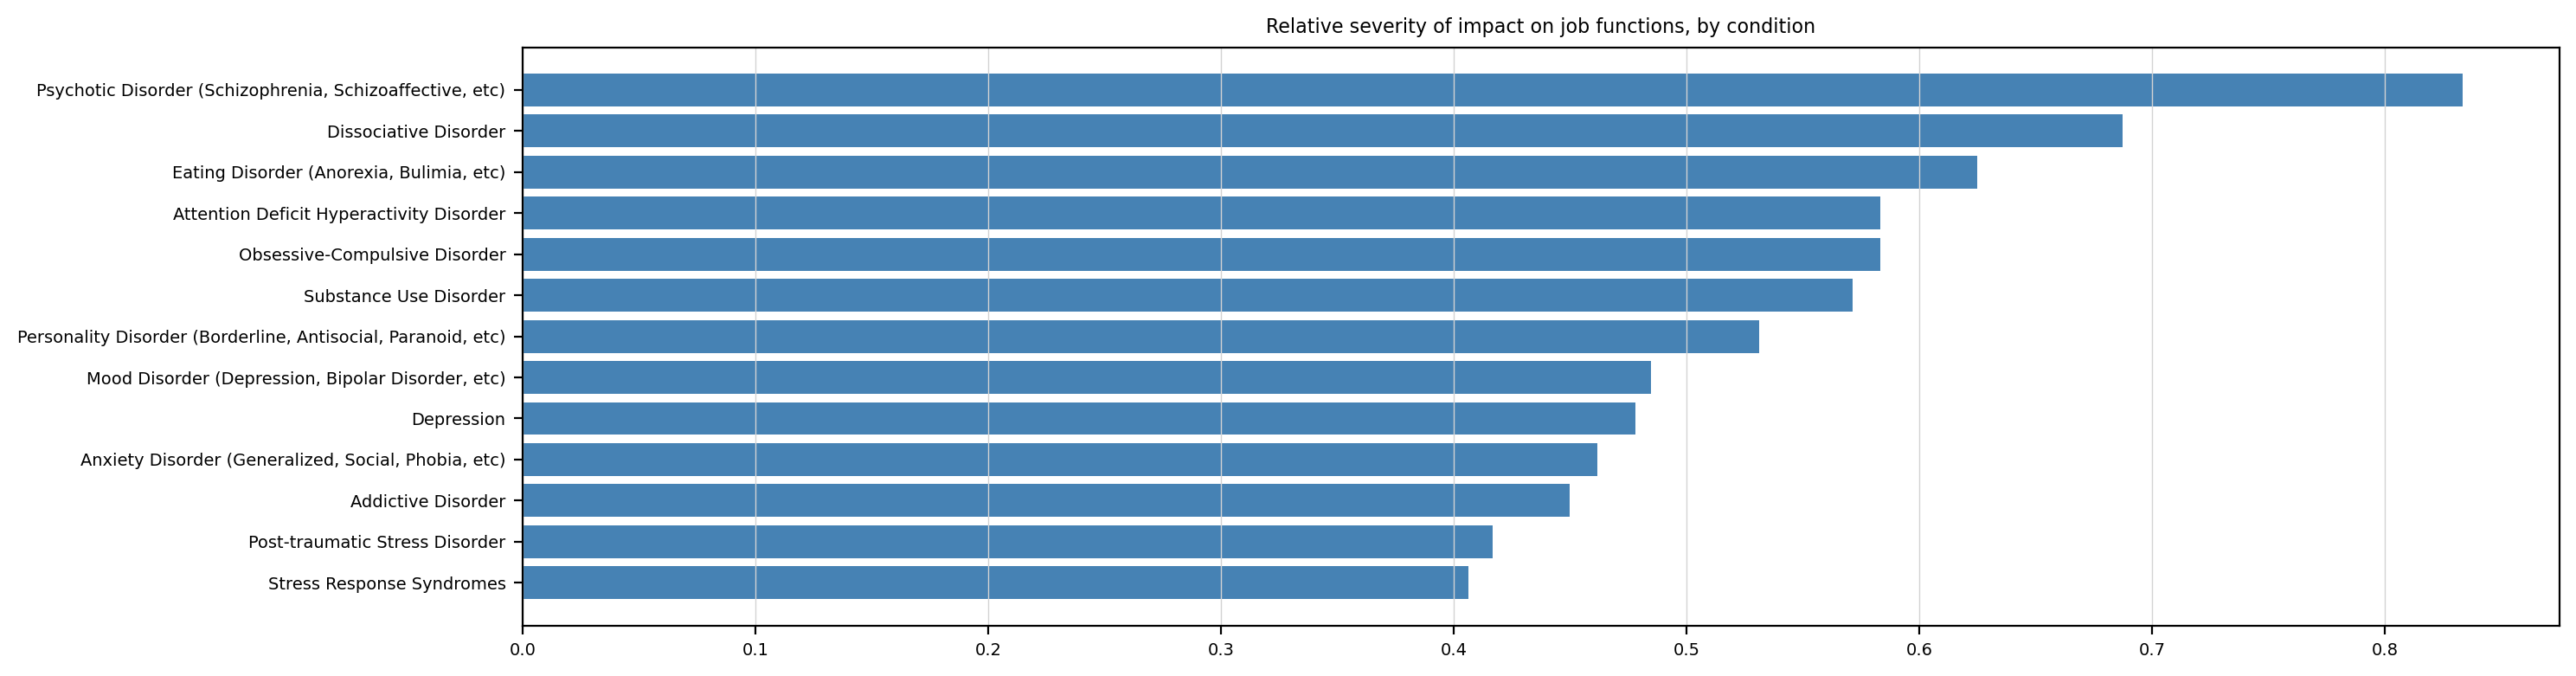

In [18]:
plt.figure(figsize = (15,4))
plt.barh(y = range(len(avg_effect_by_current_condition)), 
        width = sorted(avg_effect_by_current_condition.values(), reverse = False))
plt.yticks(range(len(avg_effect_by_current_condition)),
           [conditions_map.loc[cid, 'condition'] for cid in sorted(avg_effect_by_current_condition.keys(), 
                                                                   key= lambda c: avg_effect_by_current_condition[c], 
                                              reverse = False)], rotation = 0);
plt.title('Relative severity of impact on job functions, by condition');
plt.grid(axis = 'x', which = 'major')
plt.tight_layout()

In [19]:
wtd_effect_by_current_condition = {c: calculate_wtd_effect(c) for c in current_conditions.columns[current_conditions.sum()>5]}

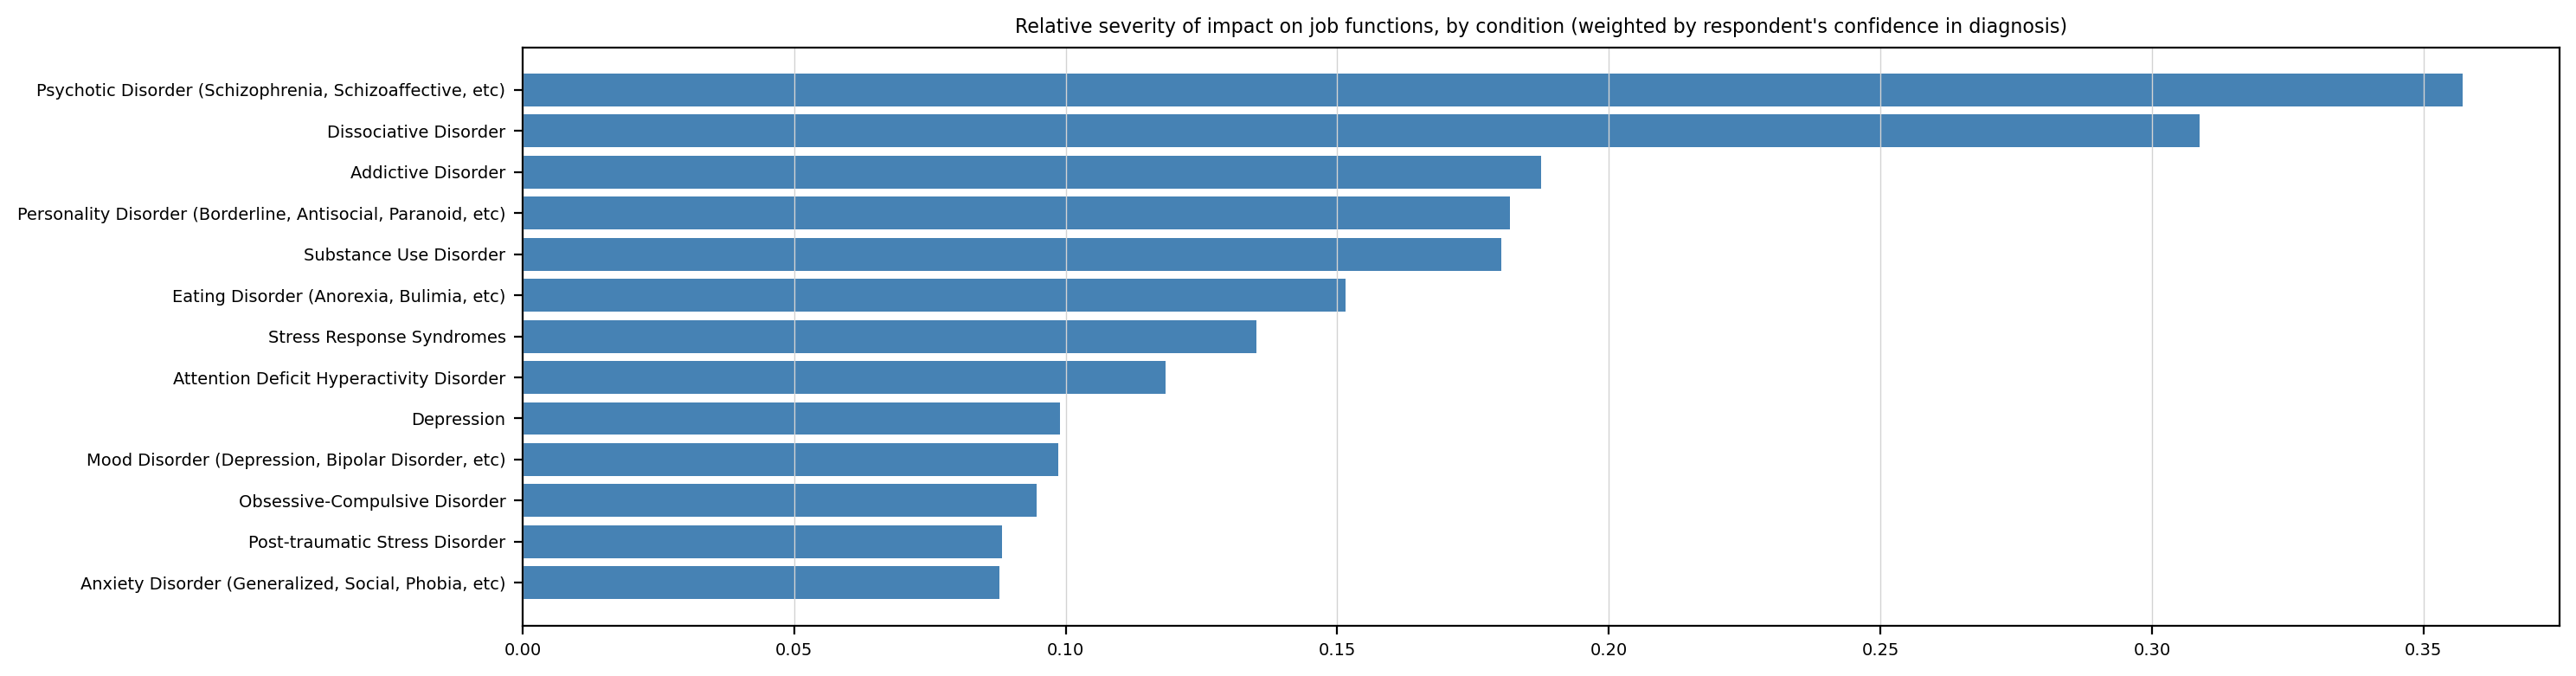

In [20]:
plt.figure(figsize = (15,4))
plt.barh(y = range(len(wtd_effect_by_current_condition)), 
        width = sorted(wtd_effect_by_current_condition.values(), reverse = False))
plt.yticks(range(len(wtd_effect_by_current_condition)),
           [conditions_map.loc[cid, 'condition'] for cid in sorted(wtd_effect_by_current_condition.keys(), 
                                                                   key= lambda c: wtd_effect_by_current_condition[c], 
                                              reverse = False)], rotation = 0);
plt.grid(axis = 'x', which = 'major')
plt.title('Relative severity of impact on job functions, by condition (weighted by respondent\'s confidence in diagnosis)');
plt.tight_layout()

##### Relationship btw condition and family history

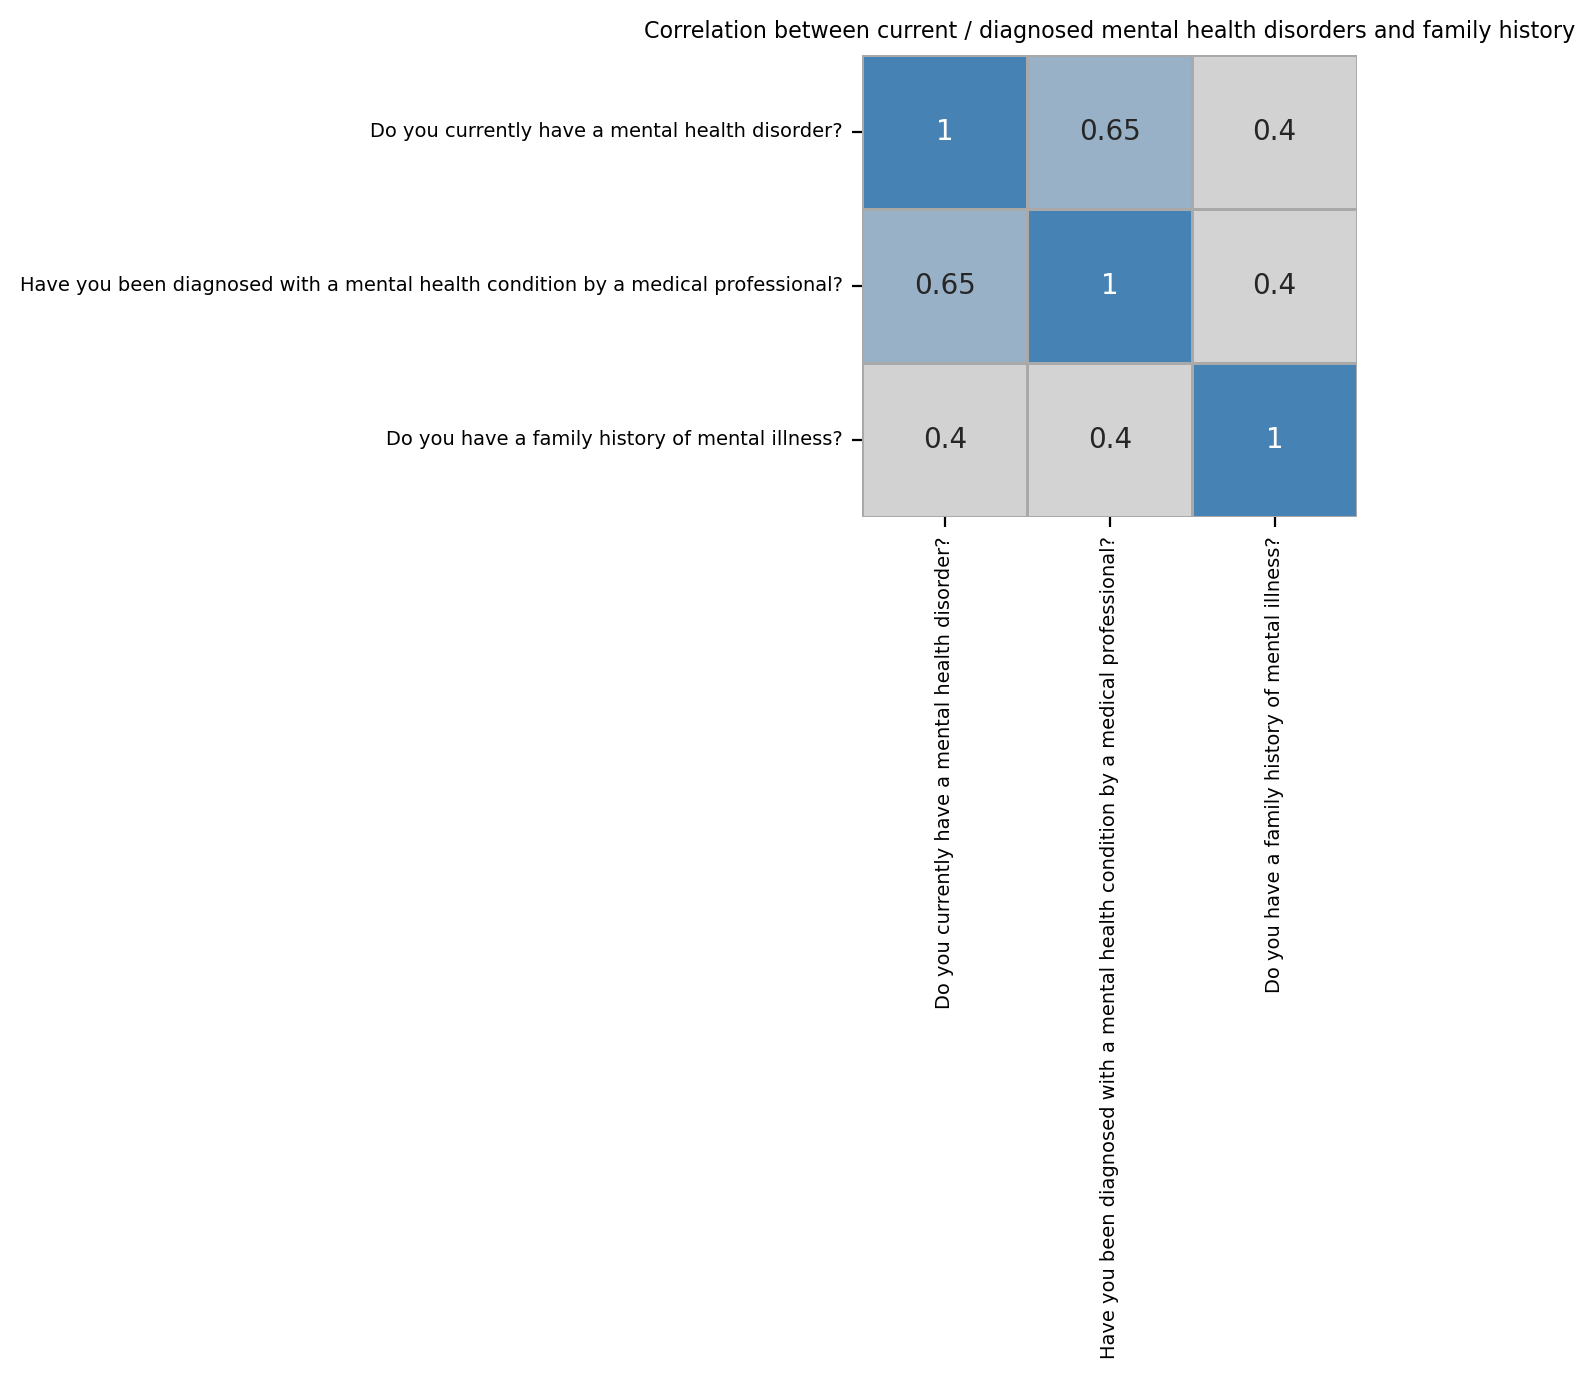

In [21]:
plt.figure(figsize = (7,7))
plt.title('Correlation between current / diagnosed mental health disorders and family history')
sns.heatmap(np.corrcoef(responses[[mhit_question_ids['Do you currently have a mental health disorder?'], 
            mhit_question_ids['Have you been diagnosed with a mental health condition by a medical professional?']]],
           responses[[mhit_question_ids['Do you have a family history of mental illness?']]], 
            #mhit_question_ids['Do you have a family history of mental illness?']]
             rowvar = False), cbar = False, annot = True, cmap = mhit_cmap, linecolor = 'darkgray', linewidth = 1, 
           xticklabels= ['Do you currently have a mental health disorder?',
                        'Have you been diagnosed with a mental health condition by a medical professional?',
                        'Do you have a family history of mental illness?'],
                      yticklabels= ['Do you currently have a mental health disorder?',
                        'Have you been diagnosed with a mental health condition by a medical professional?',
                        'Do you have a family history of mental illness?']);
plt.tight_layout()

In [23]:
cond_vs_fhist = pd.concat([df[dc_conditions].apply(lambda c: responses[[mhit_question_ids['Do you have a family history of mental illness?']]].corrwith(c, axis = 0))
                                              for df in [diagnosed_conditions, current_conditions]], axis = 0)

cond_vs_fhist.index = ['diagnosed', 'current']

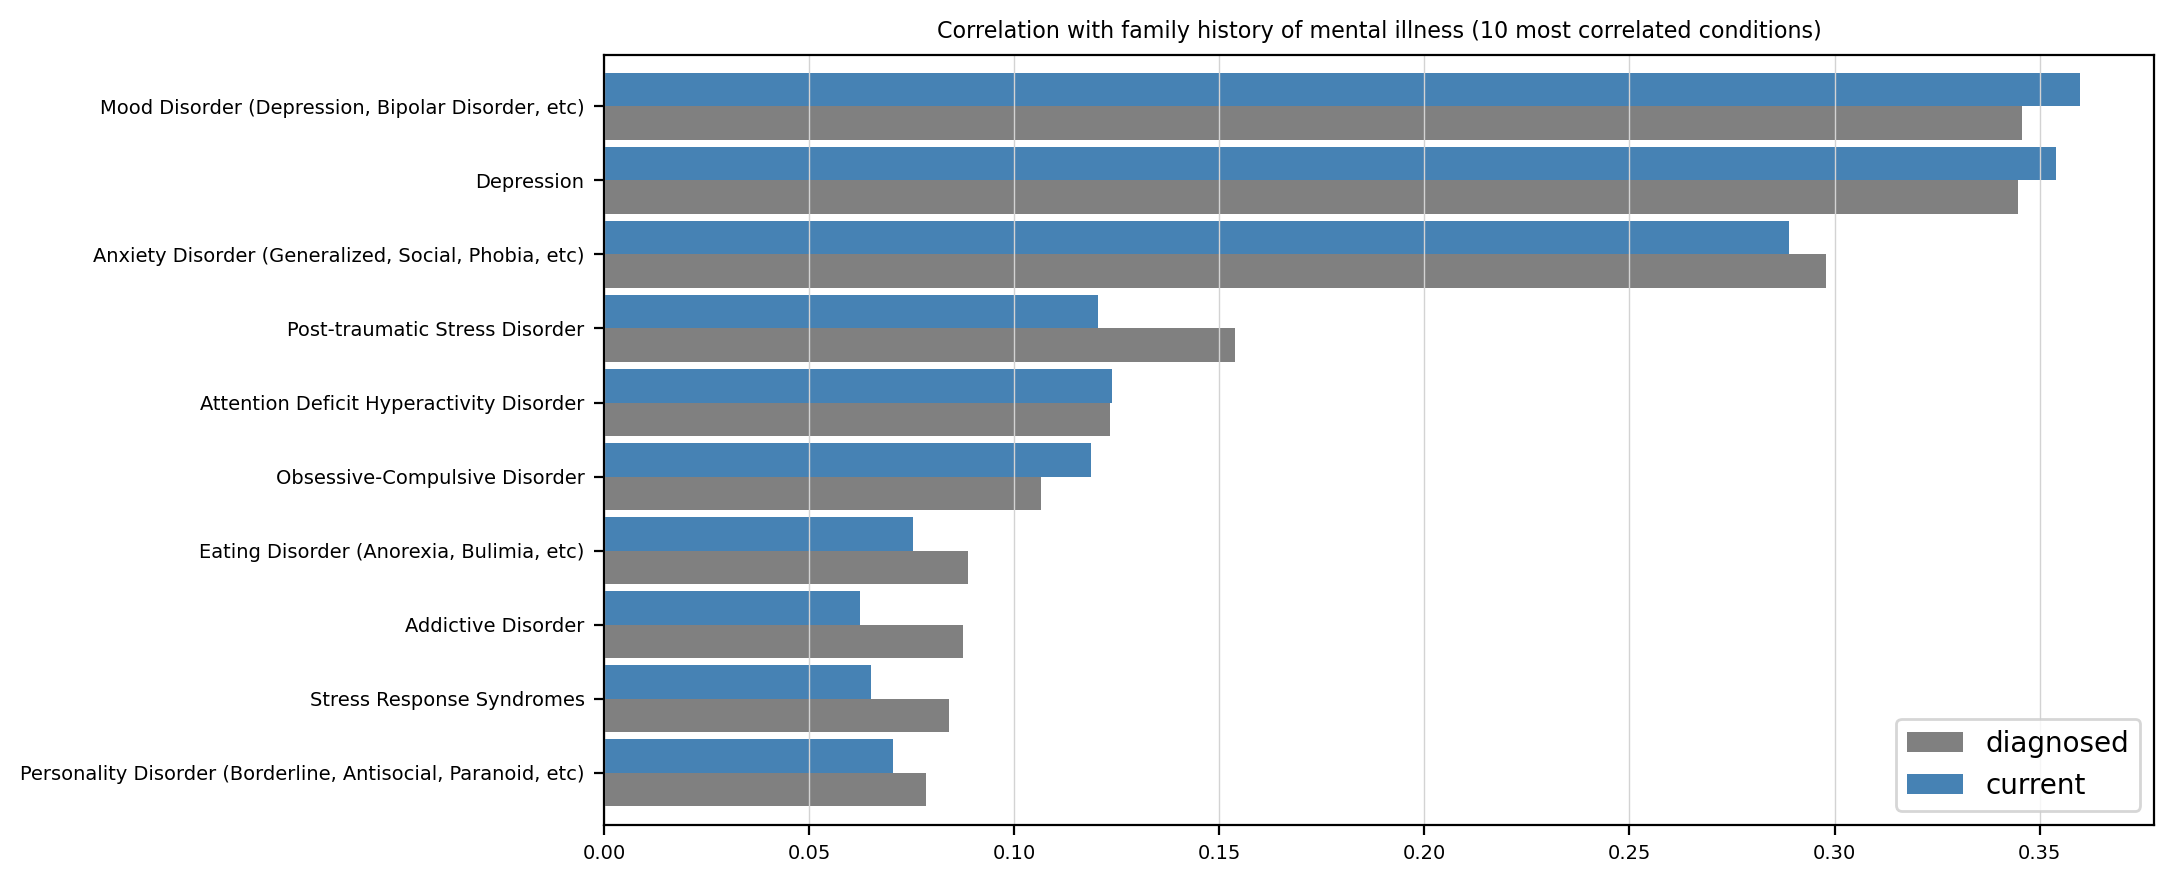

In [24]:
cond_vs_fhist[cond_vs_fhist.mean().abs().T.sort_values().index[-10:]].T.plot(kind = 'barh', color = ['gray', 'steelblue'],
                                                                 width = 0.9, figsize = (10,5));
plt.yticks(range(10), [conditions_map.loc[cid, 'condition'] for cid in cond_vs_fhist.mean().abs().T.sort_values().index[-10:]]);
plt.grid(which = 'major', axis = 'x', zorder = 0);
plt.title('Correlation with family history of mental illness (10 most correlated conditions)');

##### Relationship between diagnosed condition and condition described as "current"

In [26]:
diag_x_current_corr = diagnosed_conditions[dc_conditions].apply(lambda s: current_conditions[dc_conditions].corrwith(s, axis = 0))

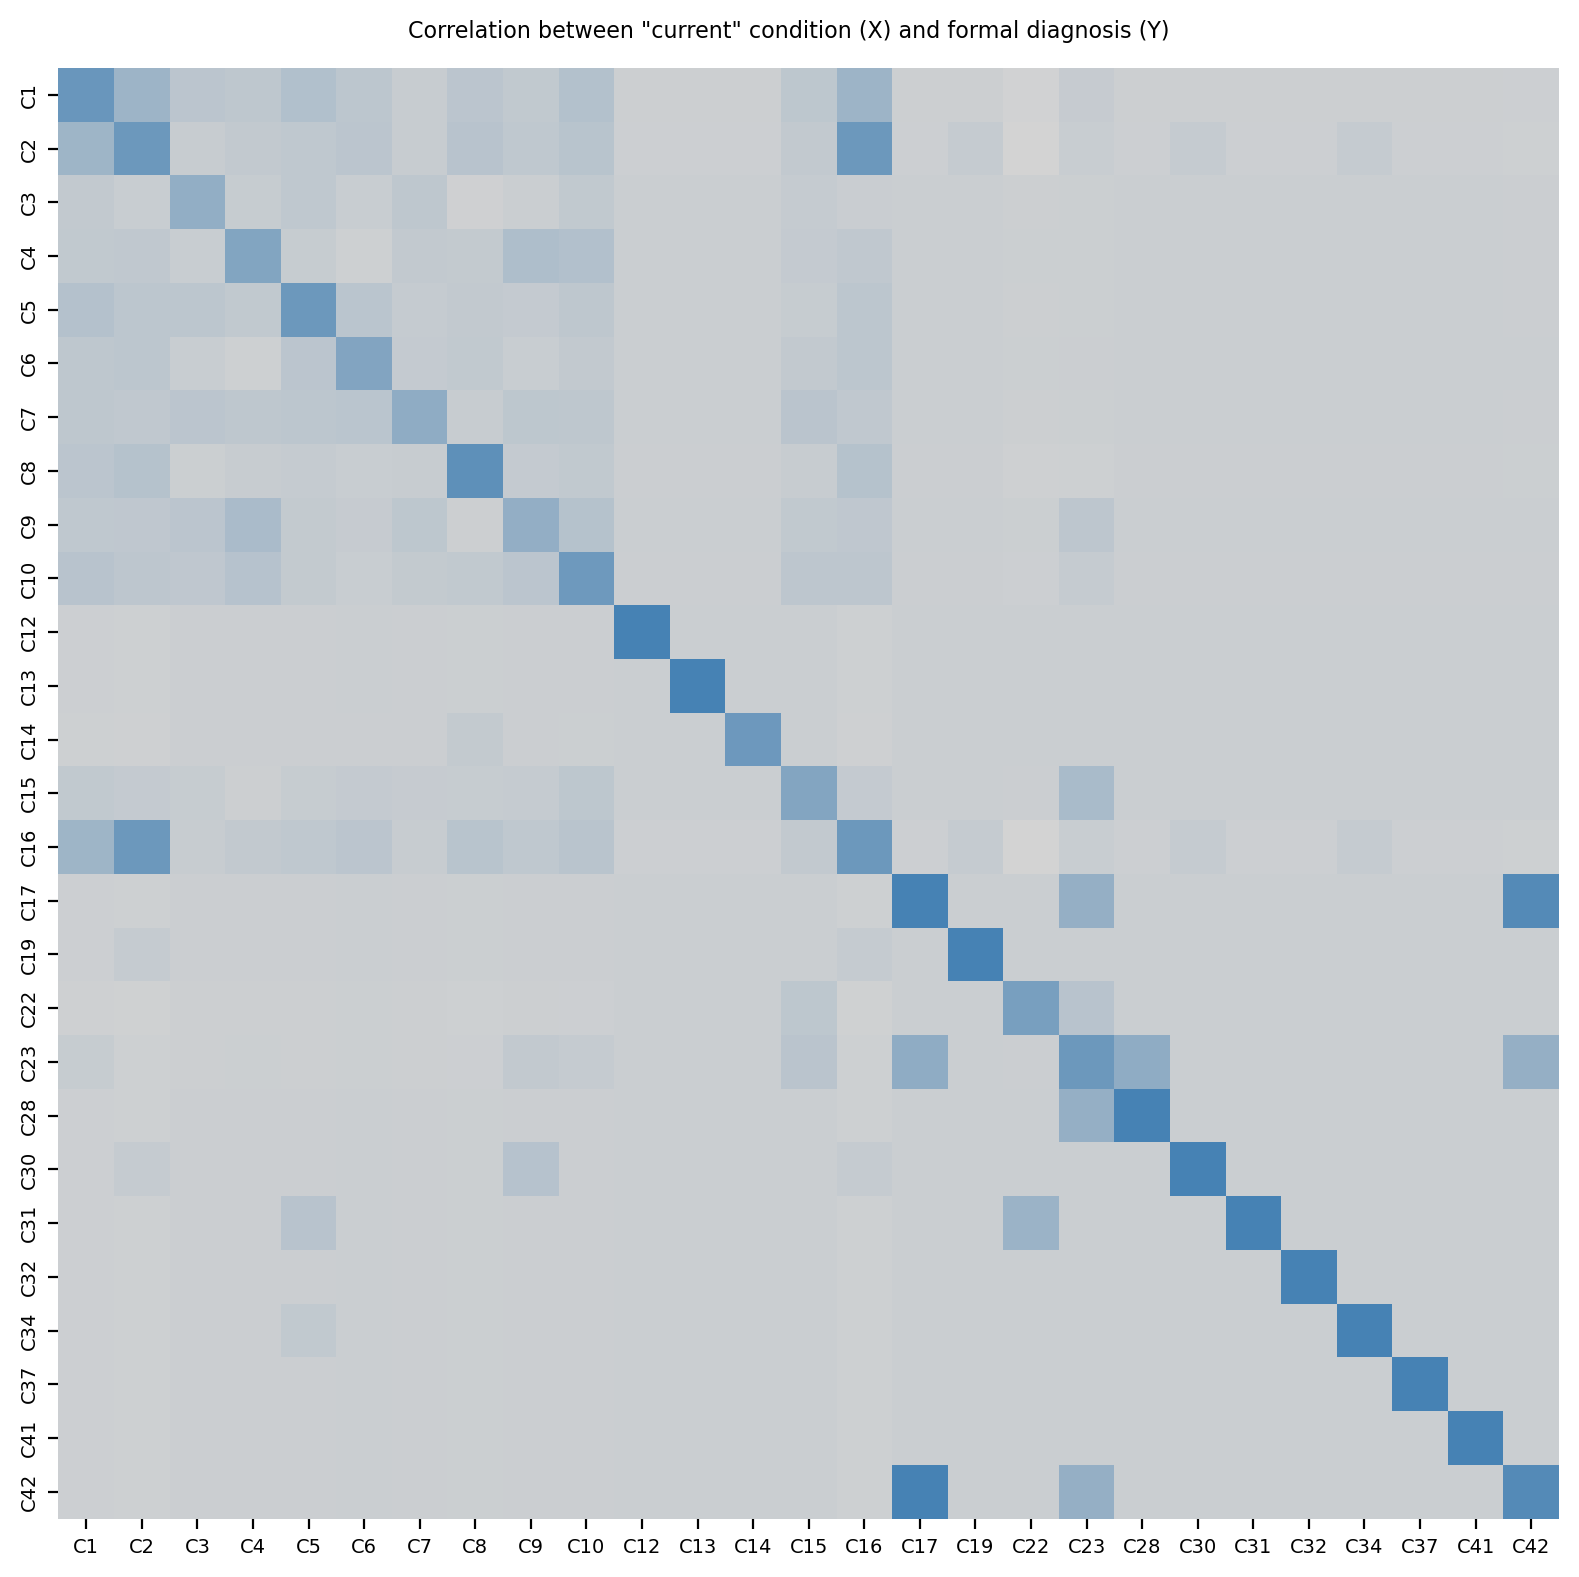

In [27]:
plt.figure(figsize = (8,8))
plt.suptitle('Correlation between "current" condition (X) and formal diagnosis (Y)')
sns.heatmap(diag_x_current_corr, xticklabels=diag_x_current_corr.columns, yticklabels=diag_x_current_corr.index, 
            cmap = mhit_cmap, cbar = False);
plt.tight_layout()

In [28]:
dc_corr = diag_x_current_corr.unstack().reset_index().rename({'level_0': 'diagnosis', 
                                                    'level_1': 'current condition', 0: 'correlation'}, 
                                                   axis = 1).sort_values('correlation', ascending = False)

In [29]:
dc_corr['diagnosis'] = dc_corr['diagnosis'].apply(lambda x: conditions_map.loc[x])
dc_corr['current condition'] = dc_corr['current condition'].apply(lambda x: conditions_map.loc[x])

In [30]:
dc_corr[dc_corr['diagnosis']!=dc_corr['current condition']].head(10)

,diagnosis,current condition,correlation
431,Autism (Asperger's),Asperger's,1.000000
717,Asperger's,Autism (Asperger's),0.894365
379,Depression,"Mood Disorder (Depression, Bipolar Disorder, etc)",0.711759
41,"Mood Disorder (Depression, Bipolar Disorder, etc)",Depression,0.710433
531,Autism Spectrum Disorder,Autism,0.446589
423,Autism (Asperger's),Autism,0.446589
505,Autism,Autism Spectrum Disorder,0.399267
501,Autism,Autism (Asperger's),0.399267
512,Autism,Asperger's,0.399267
720,Asperger's,Autism,0.398853


##### Significant differences between responses from participants with different diagnosed / current conditions

In [36]:
include_in_condition_analysis = [mhit_question_ids[q] for q in 
                                ['Do you have a family history of mental illness?',
 'Have you had a mental health disorder in the past?',
 'Have you ever sought treatment for a mental health issue from a mental health professional?',
 'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
 'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?']]

In [38]:
diagnosed_df = diagnosed_conditions[diagnosed_conditions.sum().sort_values(ascending = False).head(10).index]
diagnosed_df = diagnosed_df.unstack().reset_index()
diagnosed_df = diagnosed_df[diagnosed_df[0]==1]
diagnosed_df.rename({'level_0': 'condition'}, axis = 1, inplace = True)
diagnosed_df = diagnosed_df.merge(responses[include_in_condition_analysis], left_on = 'rid', right_index = True).drop(0, axis = 1)
diagnosed_df['condition'] = diagnosed_df['condition'].map({cid: c for cid, c in zip(conditions_map.index, conditions_map['condition'])})
diagnosed_df.sample(3)

,condition,rid,Q46,Q47,Q53,Q54,Q55
1873,"Mood Disorder (Depression, Bipolar Disorder, etc)",b9bf758e-ef57-411d-bbd9-44160a966c28,1.0,1.0,1,0.00,0.50
1235,Depression,23a4de34-da19-4000-92d8-a0143f8c2851,1.0,1.0,1,0.50,0.75
2721,"Mood Disorder (Depression, Bipolar Disorder, etc)",e269a270-739a-41e3-9e05-5f044c106c49,0.0,1.0,1,0.25,0.50


In [39]:
current_df = current_conditions[current_conditions.sum().sort_values(ascending = False).head(10).index]
current_df = current_df.unstack().reset_index()
current_df = current_df[current_df[0]==1]
current_df.rename({'level_0': 'condition'}, axis = 1, inplace = True)
current_df = current_df.merge(responses[include_in_condition_analysis], left_on = 'rid', right_index = True).drop(0, axis = 1)
current_df['condition'] = current_df['condition'].map({cid: c for cid, c in zip(conditions_map.index, conditions_map['condition'])})
current_df.sample(3)

,condition,rid,Q46,Q47,Q53,Q54,Q55
2038,"Mood Disorder (Depression, Bipolar Disorder, etc)",1212ad07-a669-42ff-bad2-df5675467d09,1.0,1.0,1,0.5,0.50
489,Depression,36d600aa-d6da-44bb-925a-385027d5b99f,1.0,1.0,1,0.5,0.75
2756,"Mood Disorder (Depression, Bipolar Disorder, etc)",fbd9ce97-9ecb-4241-89f9-83e43890c3fe,1.0,1.0,1,0.5,0.75


In [41]:
#for question in include_in_condition_analysis[:1]:
question = include_in_condition_analysis[2]
print(mhit_question_ids_rev[question])
posthoc_df = sp.posthoc_ttest(diagnosed_df, group_col = 'condition', val_col = question, 
                              equal_var=(diagnosed_df.groupby('condition')[question].std().max()
                                         -diagnosed_df.groupby('condition')[question].std().min()<=0.05), p_adjust="bonferroni")

posthoc_df.style.applymap(lambda x: "background-color:lightsteelblue" if x<0.05 else "background-color: white")

Have you ever sought treatment for a mental health issue from a mental health professional?


/var/folders/s5/1c98d9r93rg6lzxgmf01jj0m0000gn/T/ipykernel_41301/1192643195.py:8: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  posthoc_df.style.applymap(lambda x: "background-color:lightsteelblue" if x<0.05 else "background-color: white")


,Depression,"Mood Disorder (Depression, Bipolar Disorder, etc)","Anxiety Disorder (Generalized, Social, Phobia, etc)",Attention Deficit Hyperactivity Disorder,Post-traumatic Stress Disorder,Obsessive-Compulsive Disorder,Stress Response Syndromes,"Personality Disorder (Borderline, Antisocial, Paranoid, etc)",Addictive Disorder,Substance Use Disorder
Depression,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.358025,1.000000,1.000000
"Mood Disorder (Depression, Bipolar Disorder, etc)",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.333794,1.000000,1.000000
"Anxiety Disorder (Generalized, Social, Phobia, etc)",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.734528,1.000000,1.000000
Attention Deficit Hyperactivity Disorder,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.240329,1.000000,1.000000
Post-traumatic Stress Disorder,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.217966,1.000000,1.000000
Obsessive-Compulsive Disorder,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Stress Response Syndromes,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
"Personality Disorder (Borderline, Antisocial, Paranoid, etc)",0.358025,0.333794,0.734528,0.240329,0.217966,1.000000,1.000000,1.000000,1.000000,1.000000
Addictive Disorder,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Substance Use Disorder,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


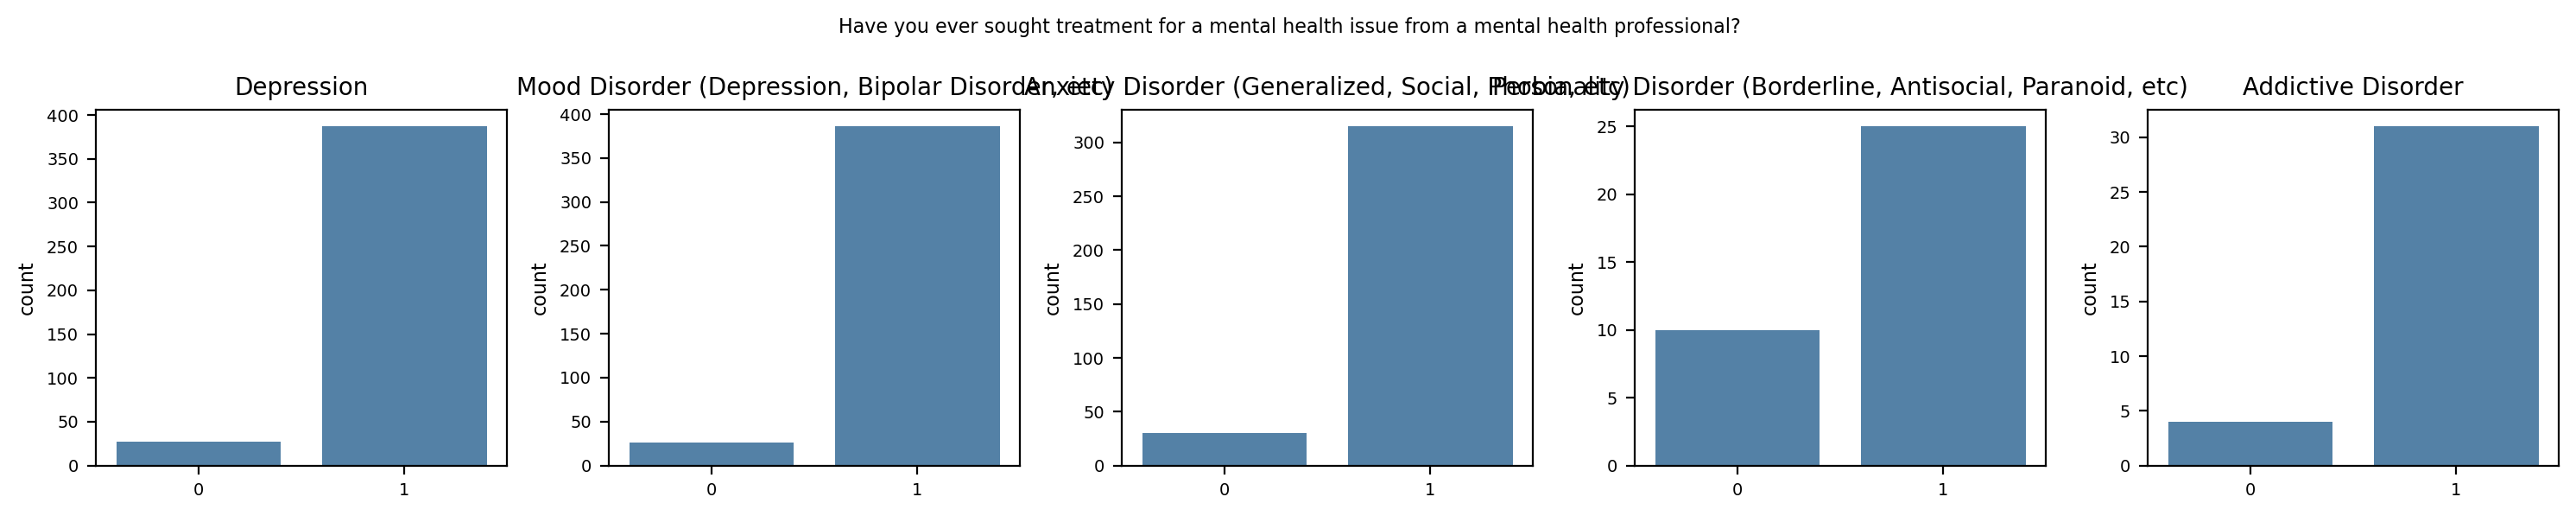

In [42]:
cwd = list(posthoc_df.columns[:3])+list(posthoc_df.columns[-3:-1])
fig, axs = plt.subplots(1,len(cwd), figsize = (len(cwd)*3,3), sharey=False)
plt.suptitle(mhit_question_ids_rev[question])
for i in range(len(cwd)):
    c = {c: cid for c, cid in zip(conditions_map['condition'], conditions_map.index)}[cwd[i]]
    sns.countplot(mhit.loc[diagnosed_conditions[diagnosed_conditions[c]==1].index], x = mhit_question_ids_rev[question], 
                  stat = 'count', ax = axs[i])
    axs[i].set_xlabel('')
    axs[i].set_title(cwd[i], fontsize = 10);
plt.tight_layout()

In [43]:
#for question in include_in_condition_analysis[:1]:
question = include_in_condition_analysis[2]
print(mhit_question_ids_rev[question])
posthoc_df = sp.posthoc_ttest(current_df, group_col = 'condition', val_col = question, equal_var=True, p_adjust="bonferroni")

#group_names= diagnosed_df['condition'].unique()
#posthoc_df.columns= group_names
#posthoc_df.index= group_names
posthoc_df.style.applymap(lambda x: "background-color:lightsteelblue" if x<0.05 else "background-color: white")

Have you ever sought treatment for a mental health issue from a mental health professional?


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/var/folders/s5/1c98d9r93rg6lzxgmf01jj0m0000gn/T/ipykernel_41301/3769584020.py:9: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  posthoc_df.style.applymap(lambda x: "background-color:lightsteelblue" if x<0.05 else "background-color: white")


,Depression,"Mood Disorder (Depression, Bipolar Disorder, etc)","Anxiety Disorder (Generalized, Social, Phobia, etc)",Attention Deficit Hyperactivity Disorder,Post-traumatic Stress Disorder,Obsessive-Compulsive Disorder,Stress Response Syndromes,"Personality Disorder (Borderline, Antisocial, Paranoid, etc)",Substance Use Disorder,"Eating Disorder (Anorexia, Bulimia, etc)"
Depression,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000095,1.000000,1.000000,1.000000
"Mood Disorder (Depression, Bipolar Disorder, etc)",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000104,1.000000,1.000000,1.000000
"Anxiety Disorder (Generalized, Social, Phobia, etc)",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.016124,1.000000,1.000000,1.000000
Attention Deficit Hyperactivity Disorder,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.069301,1.000000,1.000000,1.000000
Post-traumatic Stress Disorder,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.040232,1.000000,1.000000,1.000000
Obsessive-Compulsive Disorder,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.803530,1.000000,1.000000,1.000000
Stress Response Syndromes,0.000095,0.000104,0.016124,0.069301,0.040232,0.803530,1.000000,0.609993,0.779931,1.000000
"Personality Disorder (Borderline, Antisocial, Paranoid, etc)",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.609993,1.000000,nan,1.000000
Substance Use Disorder,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.779931,nan,1.000000,1.000000
"Eating Disorder (Anorexia, Bulimia, etc)",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


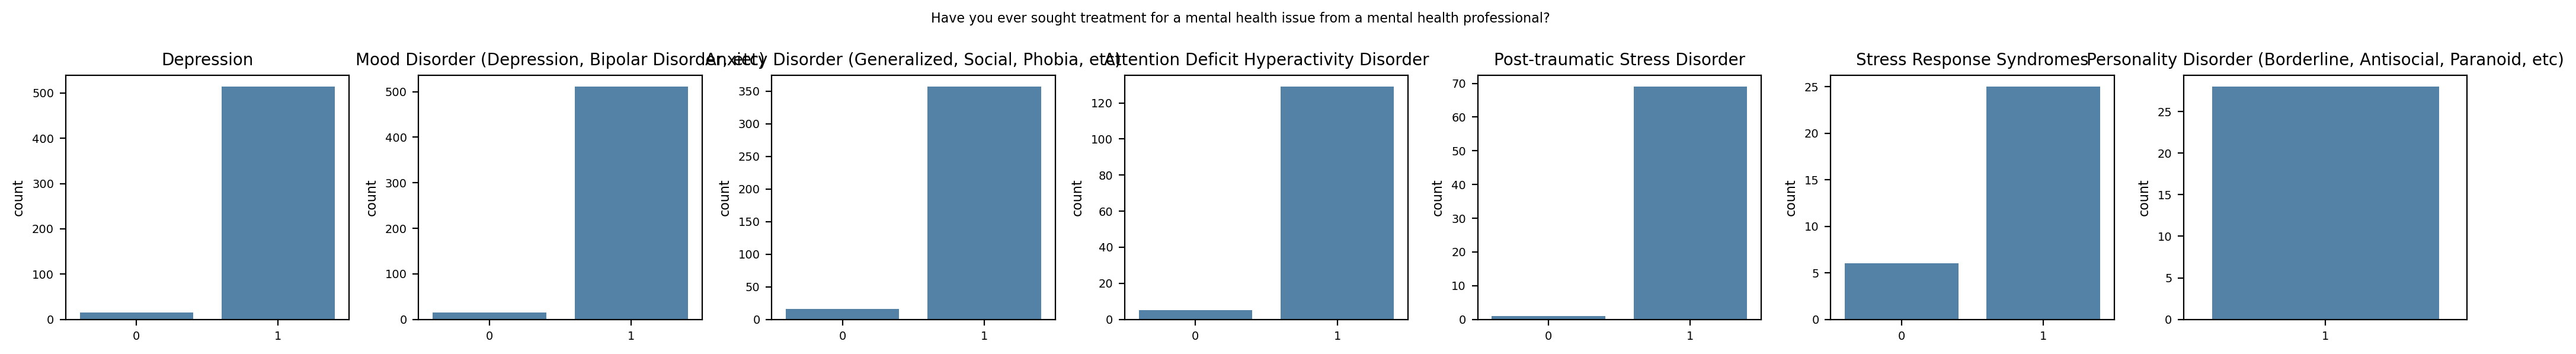

In [44]:
cwd = list(posthoc_df.columns[:5])+list(posthoc_df.columns[-4:-2])
fig, axs = plt.subplots(1,len(cwd), figsize = (len(cwd)*3,3), sharey=False)
plt.suptitle(mhit_question_ids_rev[question])
for i in range(len(cwd)):
    c = {c: cid for c, cid in zip(conditions_map['condition'], conditions_map.index)}[cwd[i]]
    sns.countplot(mhit.loc[current_conditions[current_conditions[c]==1].index], x = mhit_question_ids_rev[question], 
                  stat = 'count', ax = axs[i])
    axs[i].set_xlabel('')
    axs[i].set_title(cwd[i], fontsize = 10);
plt.tight_layout()

##### Relationship between experienced impact of condition and decision to seek treatment

/var/folders/s5/1c98d9r93rg6lzxgmf01jj0m0000gn/T/ipykernel_41301/1171769010.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


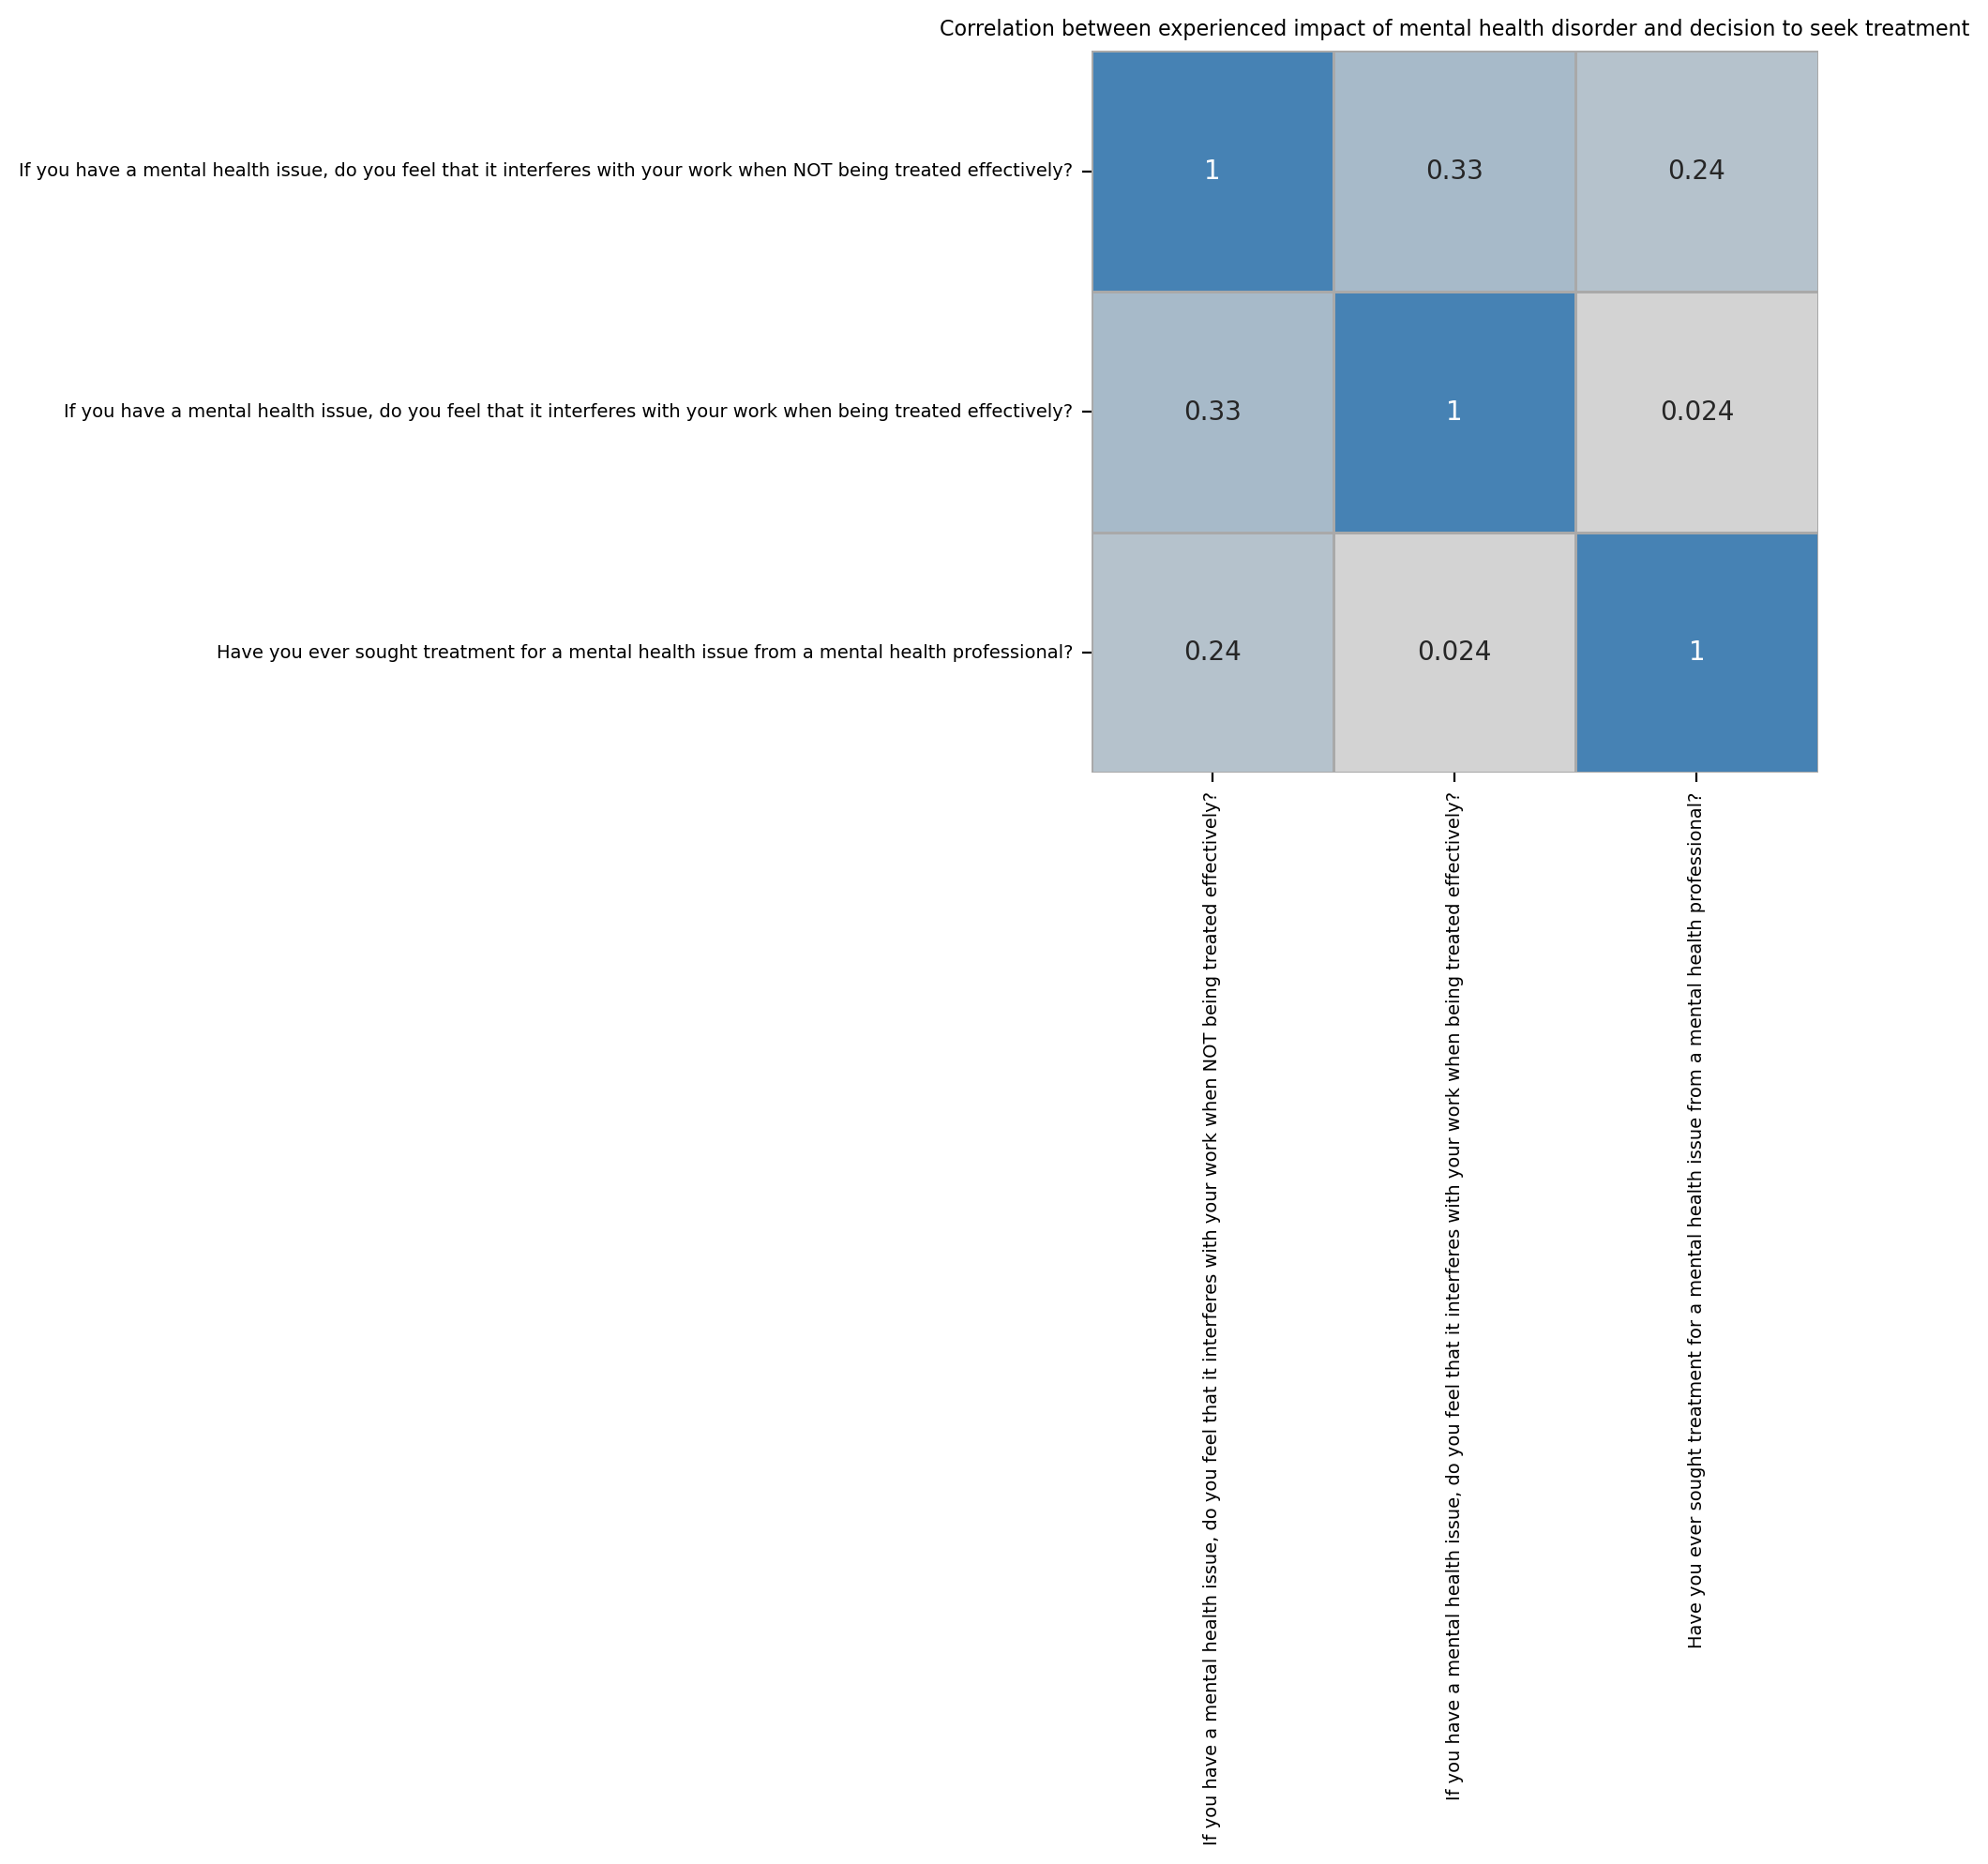

In [45]:
impact_trtmt_qs = [mhit_question_ids['If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?'], 
            mhit_question_ids['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'],
           mhit_question_ids['Have you ever sought treatment for a mental health issue from a mental health professional?']]

plt.figure(figsize = (5,5))
plt.title('Correlation between experienced impact of mental health disorder and decision to seek treatment')
sns.heatmap(np.corrcoef(responses.dropna(subset = impact_trtmt_qs)[impact_trtmt_qs], rowvar = False), 
            cbar = False, annot = True, cmap = mhit_cmap, linecolor = 'darkgray', linewidth = 1, 
           xticklabels= [mhit_question_ids_rev[q] for q in impact_trtmt_qs], 
            yticklabels= [mhit_question_ids_rev[q] for q in impact_trtmt_qs]);
plt.tight_layout()

#### 2. Policies, attitudes and perceptions: analysis

##### policy by type of organization / location

In [48]:
def show_breakdown(question, group_question, order_groups = None):
    
    num_to_verbal = {'values': {n: v for v, n in zip(mhit[question].dropna(), 
                                          responses[mhit_question_ids[question]].dropna())}}
    
    n = min([mhit[group_question].nunique(), 6])
    fig, axs = plt.subplots(1, n, figsize = (4*n,4), sharey=True)
    plt.suptitle(question)
    i = 0
    if order_groups:
        ordered_vs = order_groups
    else:
        ordered_vs = mhit.groupby(group_question)[group_question].count().sort_values(ascending = False).index[:n]
                 
    for v in ordered_vs:
        sns.countplot(mhit[mhit[group_question]==v], 
                      x = question, stat='percent', 
                     order = [num_to_verbal['values'][n] for n in sorted(num_to_verbal['values'].keys(), 
                                                               reverse = ('Yes' in num_to_verbal['values'][0]))], ax = axs[i], 
                      color = mhit_cmap(list(mhit.groupby(group_question)[group_question].count().sort_values(ascending = False).index).index(v)/(n-1)), 
                      alpha = 1, legend= False
                 );
        if 0 in mhit[group_question].dropna().unique():
            axs[i].set_title(f"{['non-tech', 'tech'][int(v)]}")
        else:
            axs[i].set_title(v)
        axs[i].set_xlabel('')
        axs[i].grid(axis = 'y', which = 'major', zorder = 1)
        i +=1 
    plt.tight_layout()
    plt.show()

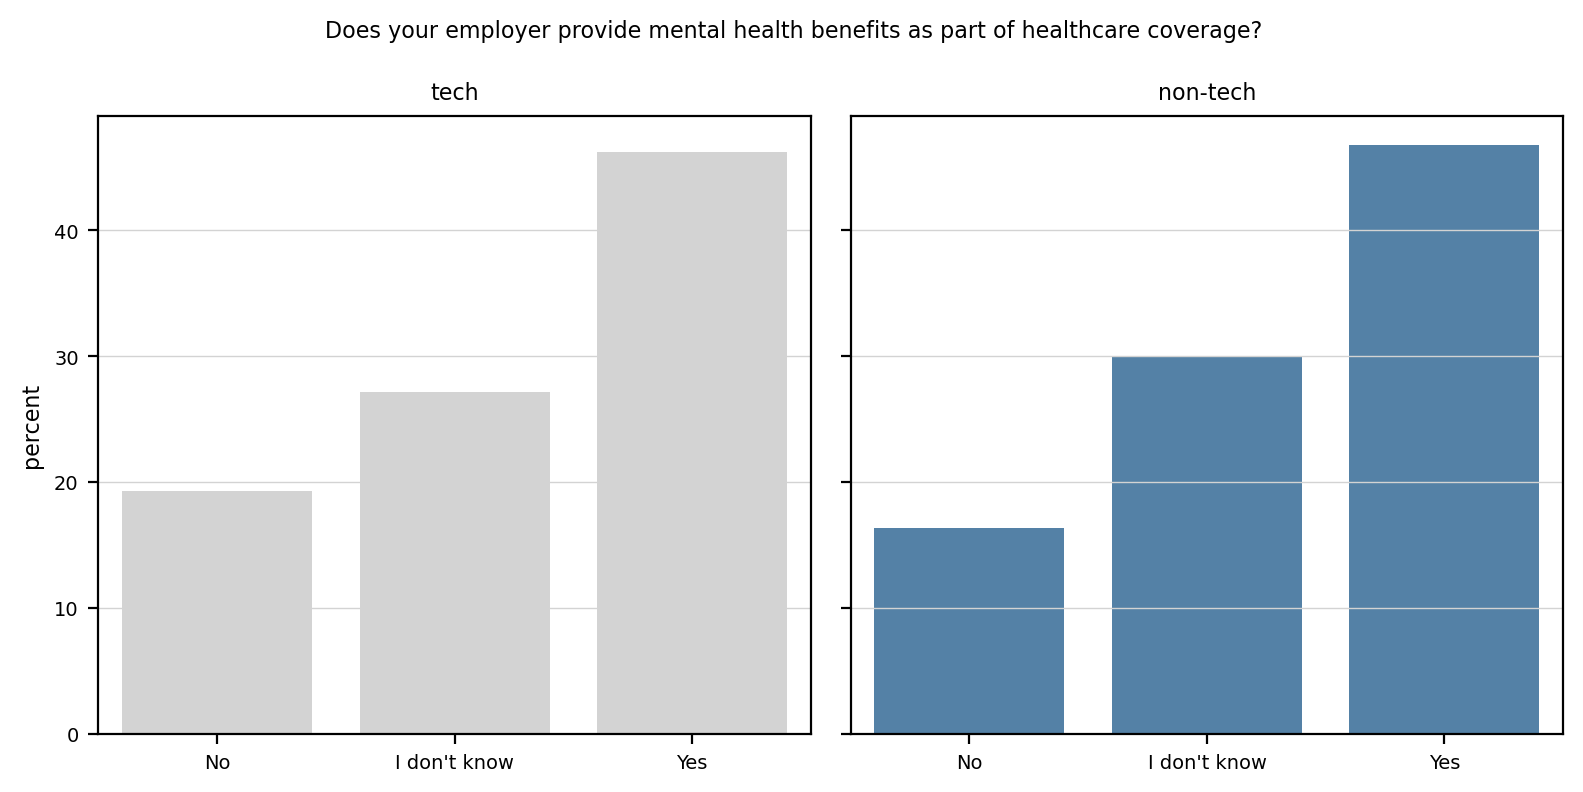

In [49]:
show_breakdown(question = 'Does your employer provide mental health benefits as part of healthcare coverage?',
                  group_question = 'Is your employer primarily a tech company/organization?')

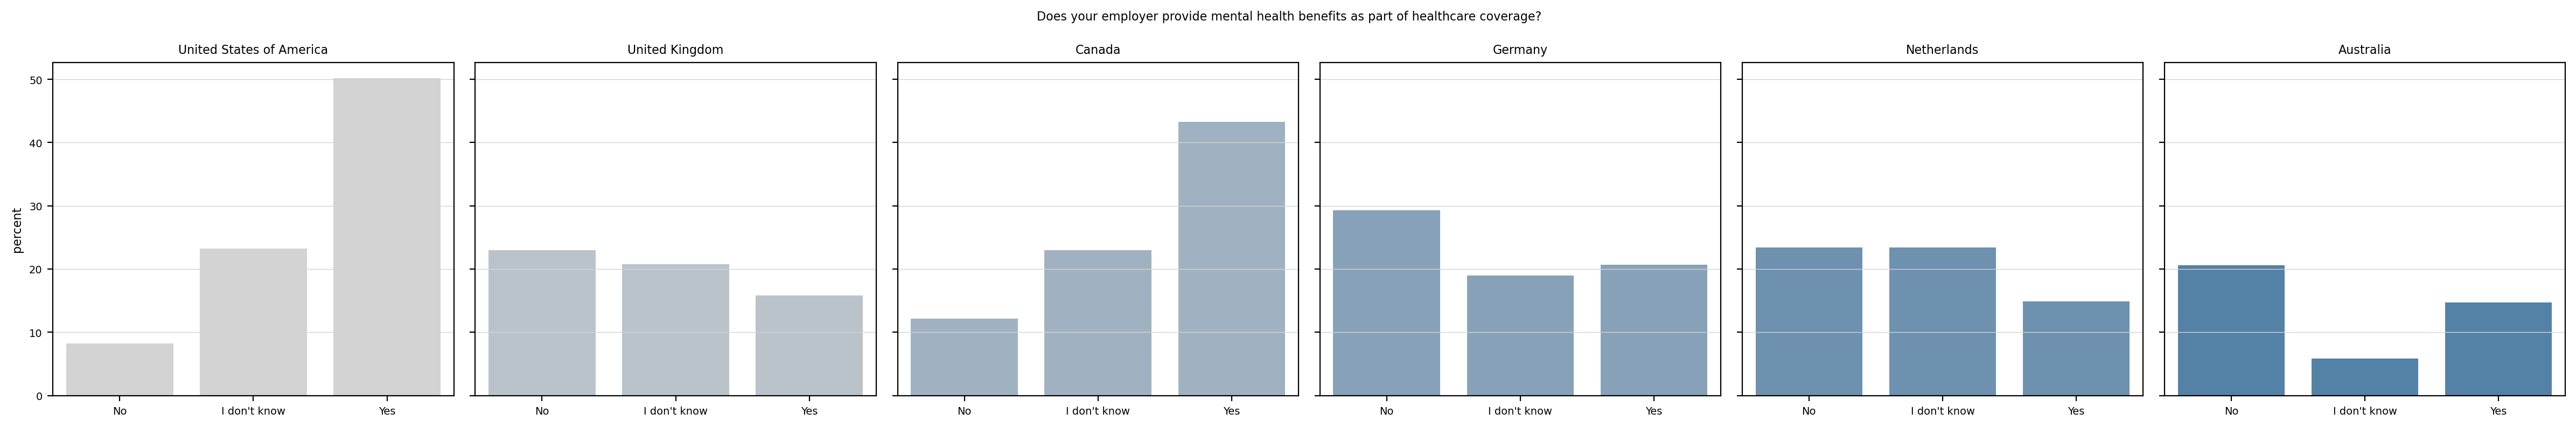

In [50]:
show_breakdown(question = 'Does your employer provide mental health benefits as part of healthcare coverage?',
                  group_question = 'What country do you work in?')

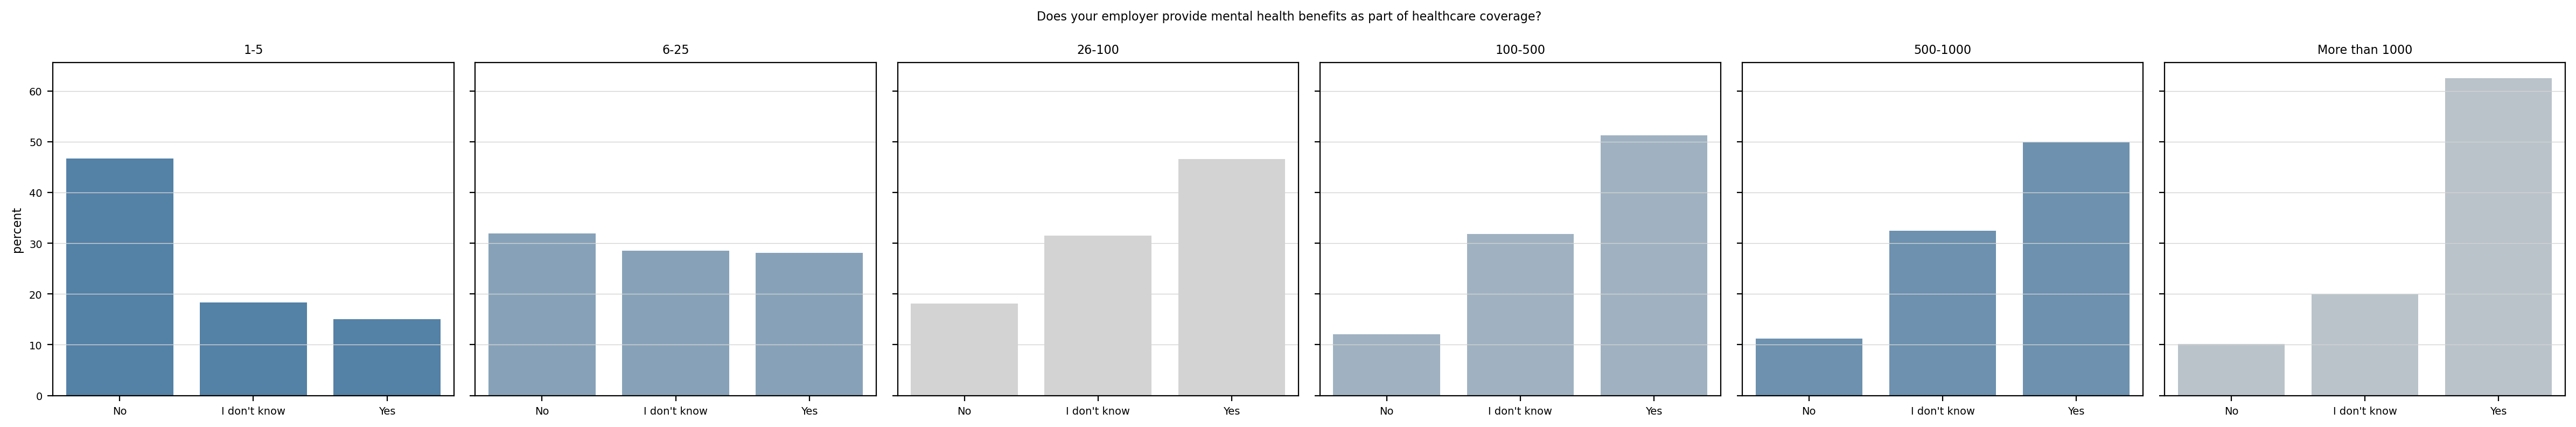

In [51]:
show_breakdown(question = 'Does your employer provide mental health benefits as part of healthcare coverage?',
                  group_question = 'How many employees does your company or organization have?', 
               order_groups= ['1-5', '6-25', '26-100','100-500', '500-1000','More than 1000'])

##### policy vs treatment-seeking

/var/folders/s5/1c98d9r93rg6lzxgmf01jj0m0000gn/T/ipykernel_41301/4162693973.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


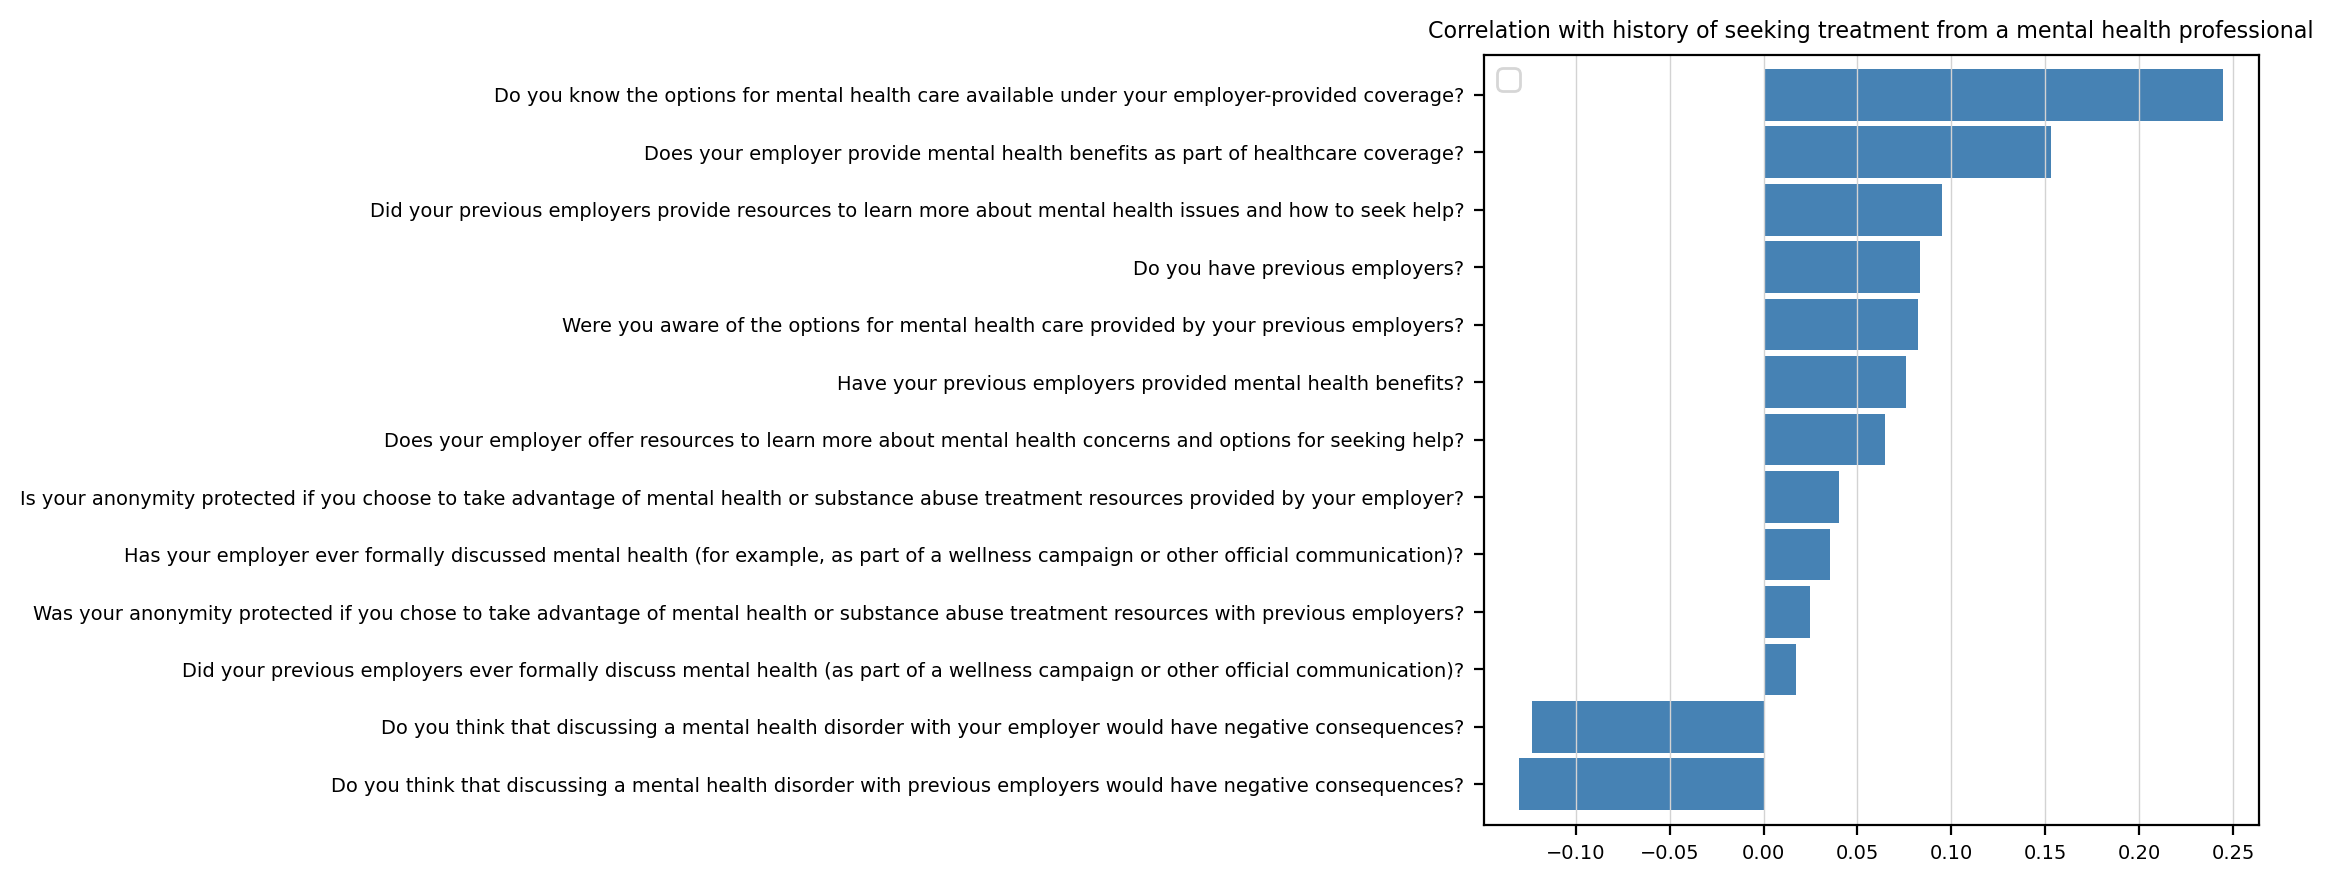

In [52]:
policy_questions = [q for q in responses.columns if 'employer' in mhit_question_ids_rev[q] 
                    and not any([_ in mhit_question_ids_rev[q] for _ in ['potential', 'physical']])]

trt_vs_policy = responses[policy_questions].apply(lambda c: responses[[mhit_question_ids['Have you ever sought treatment for a mental health issue from a mental health professional?']]].corrwith(c, axis = 0))

trt_vs_policy.index = ['sought_trt']

trt_vs_policy[trt_vs_policy.mean().T.sort_values().index].T.plot(kind = 'barh', color = 'steelblue',
                                                                 width = 0.9, figsize = (5,5));
plt.yticks(range(trt_vs_policy.shape[1]), [mhit_question_ids_rev[qid] for qid in trt_vs_policy.mean().T.sort_values().index]);
plt.grid(which = 'major', axis = 'x', zorder = 0);
plt.title('Correlation with history of seeking treatment from a mental health professional');
plt.legend('')
plt.tight_layout()

##### shifts from previous employee/-s to current employee

In [56]:
def prev_curr_employer(questions):
    widths = {}
    widths = {['left', 'right'][i]: (responses[mhit_question_ids[questions[i]]].value_counts()/
                      responses[mhit_question_ids[questions[i]]].dropna().shape[0]) for i in range(2)}
    
    lower_bounds = {side: [] for side in ['left', 'right']}
    upper_bounds = {side: [] for side in ['left', 'right']}
    for side in ['left', 'right']:
        for i in sorted(widths[side].index):
            try:
                lower_bounds[side].append(upper_bounds[side][-1])
                upper_bounds[side].append(lower_bounds[side][-1]+widths[side].loc[i])
            except:
                lower_bounds[side].append(0)
                upper_bounds[side].append(widths[side].loc[i])
    
    fig, ax = plt.subplots(1,1, figsize = (6,4))
    sax = ax.twinx()
    left_labels = [{i: w for i, w in zip(responses[mhit_question_ids[questions[0]]], mhit[questions[0]])}[i] for i in sorted(widths['left'].index)]
    right_labels = [{i: w for i, w in zip(responses[mhit_question_ids[questions[1]]], mhit[questions[1]])}[i] for i in sorted(widths['right'].index)]
    if left_labels == right_labels:
        labels = left_labels
    else:
        labels = [f"{left_labels[i]} / {right_labels[i]}" for i in range(len(left_labels))]
    for i in range(len(widths['left'])):
        plt.fill_between([0,1], y1 = np.array([upper_bounds['left'][i],
                                                upper_bounds['right'][i]]), y2= np.array([lower_bounds['left'][i],
                                                                                       lower_bounds['right'][i]]),
                                              alpha=0.3, cmap = mhit_cmap, color = mhit_cmap(np.linspace(0,1,len(widths['left']))[i]), 
                         label = labels[i]
                        )
    
    # Customize the plot
    ax.set_xticks([])
    ax.set_xmargin(0)
    ax.set_ylabel('Previous employer/-s')
    sax.set_ylabel('Current employer')
    ax.set_yticks([np.mean([lower_bounds['left'][i], upper_bounds['left'][i]]) for i in range(len(lower_bounds['left']))], 
                  ["{:.0%}".format(widths['left'].loc[i]) for i in sorted(widths['left'].index)])
    sax.set_yticks([np.mean([lower_bounds['right'][i], upper_bounds['right'][i]]) for i in range(len(lower_bounds['right']))], 
                  ["{:.0%}".format(widths['right'].loc[i]) for i in sorted(widths['right'].index)])
    ax.set_title(questions[1].replace('employer', 'previous/current employer(-s)'))
    sax.legend()
    sax.set_ymargin(0)
    plt.tight_layout()
    plt.show()

In [54]:
question_sets = [['Have your previous employers provided mental health benefits?',
                    'Does your employer provide mental health benefits as part of healthcare coverage?'],
                ['Were you aware of the options for mental health care provided by your previous employers?',
                   'Do you know the options for mental health care available under your employer-provided coverage?'],
                ['Did you feel that your previous employers took mental health as seriously as physical health?',
                     'Do you feel that your employer takes mental health as seriously as physical health?'],
                ['Do you think that discussing a mental health disorder with previous employers would have negative consequences?',
                   'Do you think that discussing a mental health disorder with your employer would have negative consequences?'],
                ['Do you think that discussing a physical health issue with previous employers would have negative consequences?',
                   'Do you think that discussing a physical health issue with your employer would have negative consequences?']]

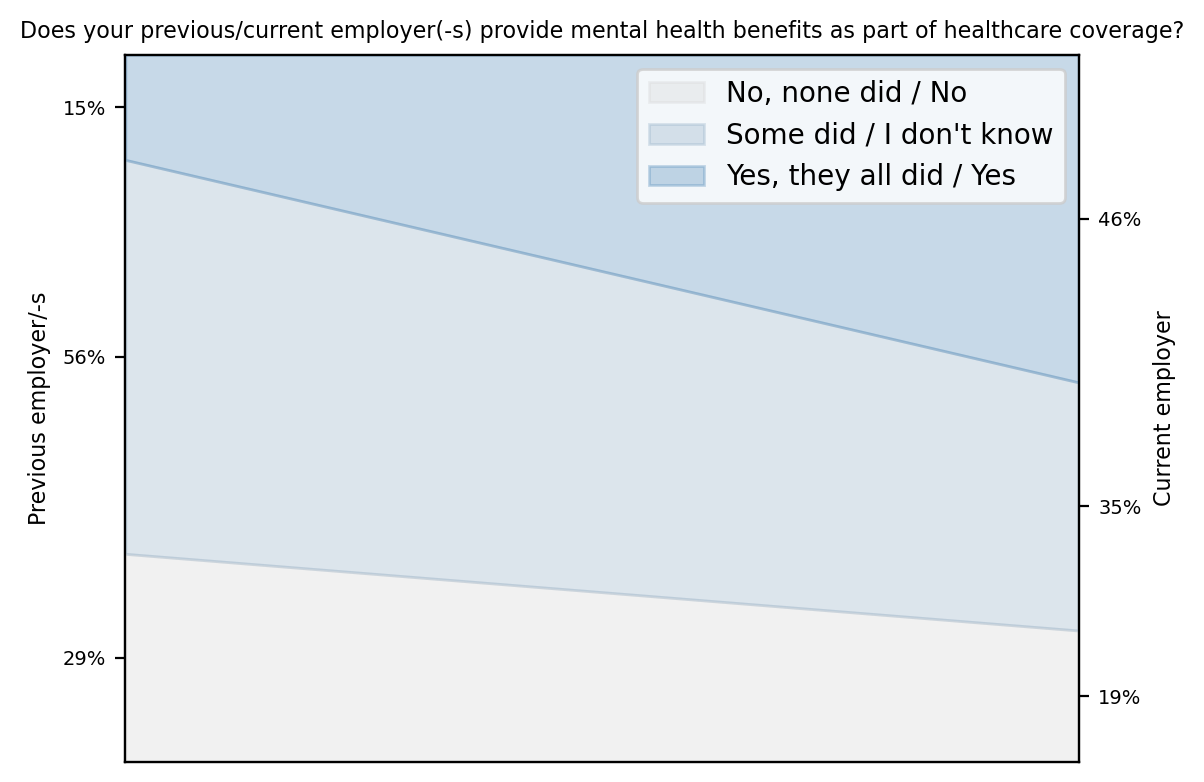

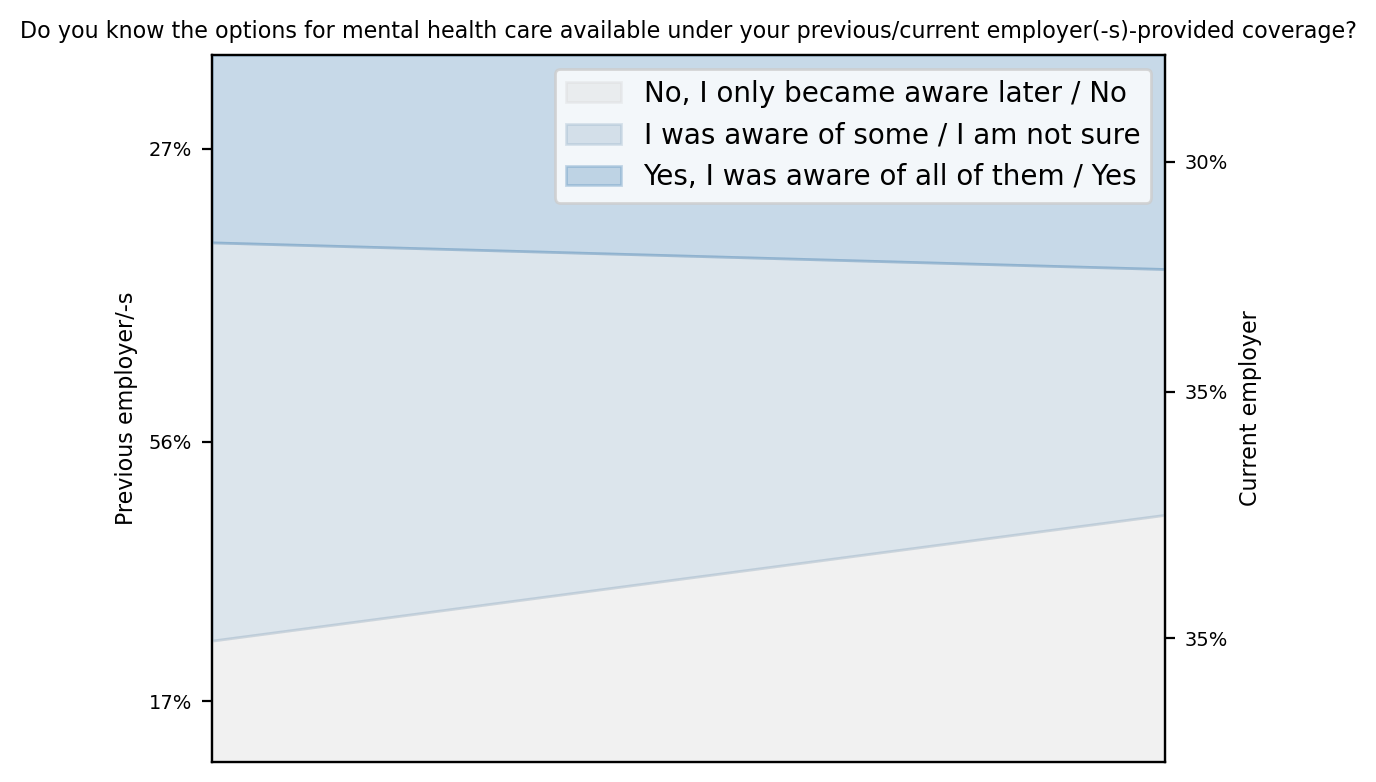

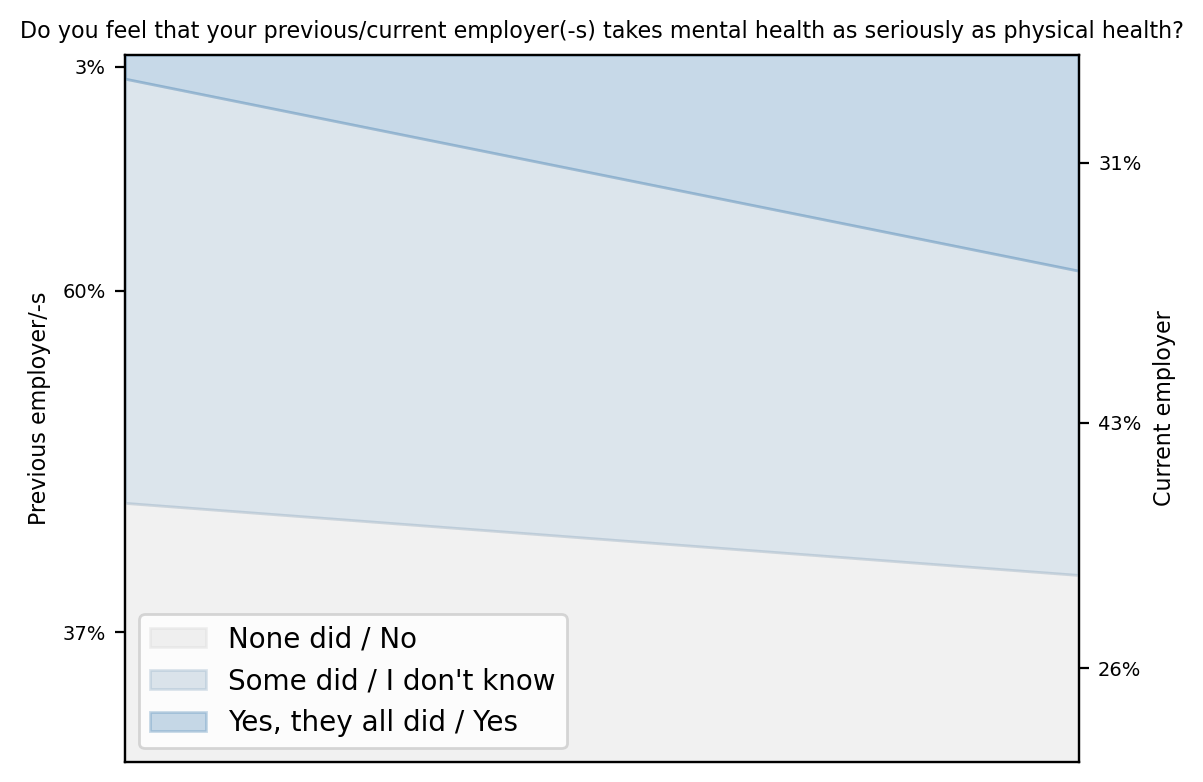

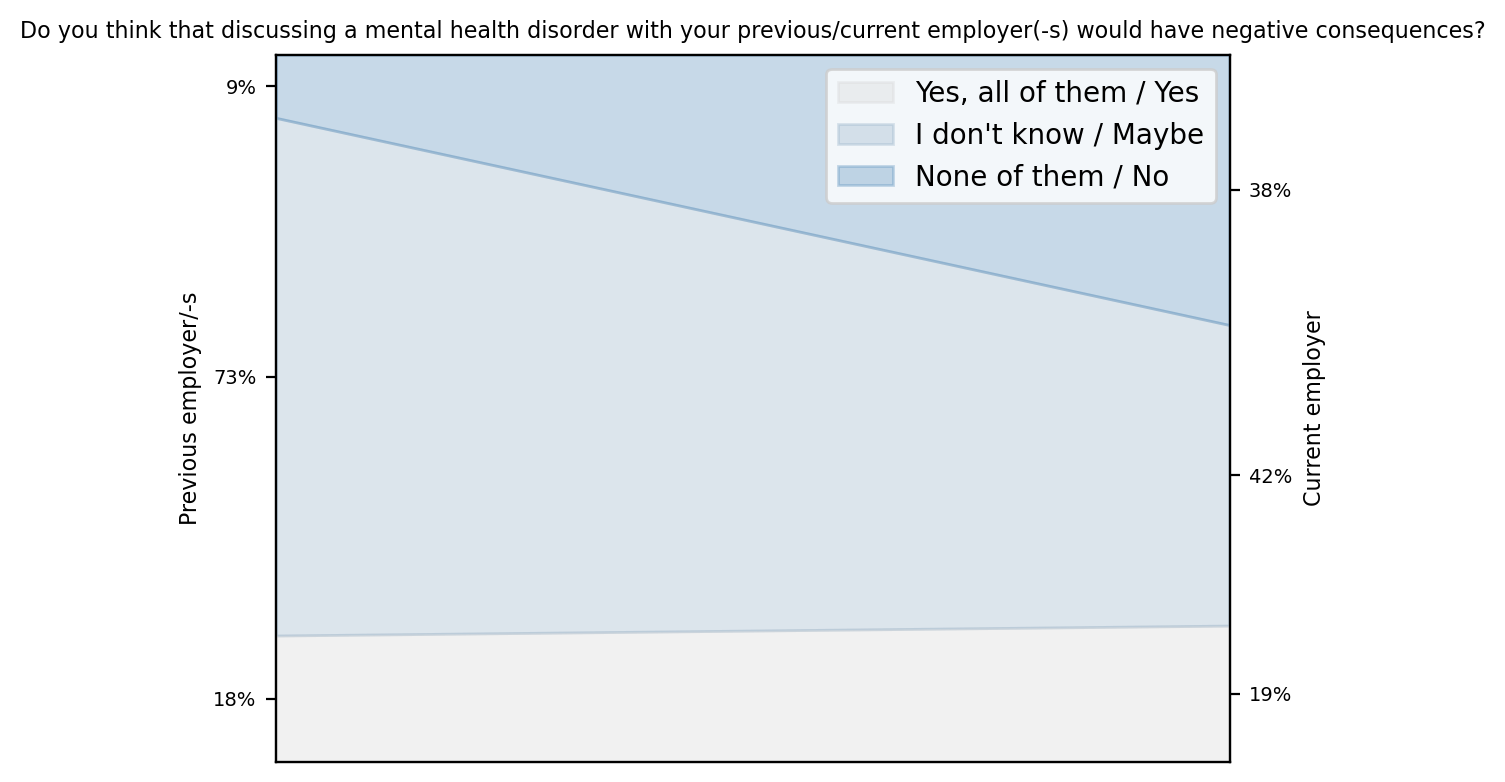

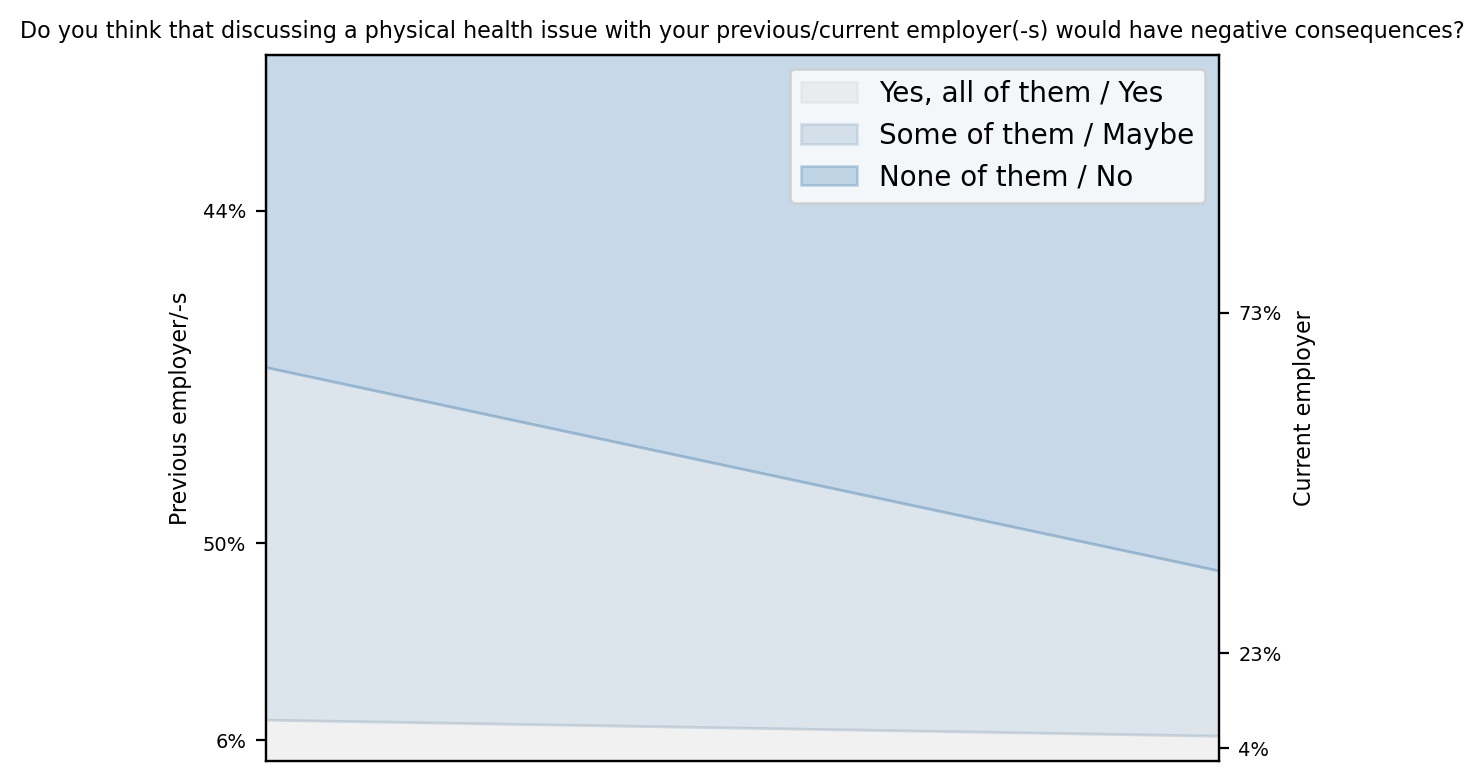

In [57]:
for q_set in question_sets:
    prev_curr_employer(q_set)

#### 3. Policies, attitudes and perceptions: hypothesis testing

In [58]:
def check_normality(q):
    data = responses[mhit_question_ids[q]].dropna()
    test_stat_normality, p_value_normality=stats.shapiro(data)
    if p_value_normality <0.05:
        return False 
    else:
        return True 

def check_variance_homogeneity(questions):
    q1, q2 = questions
    data = responses[[mhit_question_ids[q1], mhit_question_ids[q2]]].dropna()
    test_stat_var, p_value_var= stats.levene(data[mhit_question_ids[q1]],data[mhit_question_ids[q2]])
    if p_value_var <0.05:
        return False
    else:
        return True

def check_significant_diff_paired(questions):
    q1, q2 = questions
    data = responses[[mhit_question_ids[q1], mhit_question_ids[q2]]].dropna()
    if check_normality(q1) and check_normality(q2):
        if check_variance_homogeneity(q1, q2):
            
            t_stat, p_value = ttest_rel(data[mhit_question_ids[q1]],data[mhit_question_ids[q2]], 
                                        equal_var= (abs(data[mhit_question_ids[q1]].std()-data[mhit_question_ids[q2]].std())<0.05))
    else:
        w_stat, p_value = wilcoxon(data[mhit_question_ids[q1]],data[mhit_question_ids[q2]])

    if p_value < 0.05:
        return True
    else:
        return False

In [59]:
def show_physical_vs_mental(questions):
    num_to_verbal = {n: v for v, n in zip(mhit[questions[0]].dropna(), 
                                          responses[mhit_question_ids[questions[0]]].dropna())}
    fig, axs = plt.subplots(1,2, figsize = (10, 4), sharey=True)
    plt.suptitle(f"{questions[0]}\nvs {questions[1]}", fontsize = 11)
    for i in range(2):
        sns.countplot(data = mhit,
                     x = questions[i], color = ['gray', 'steelblue'][i], stat = 'percent', ax = axs[i],
                      order = [num_to_verbal[n] for n in sorted(num_to_verbal.keys(), reverse = ('Yes' in num_to_verbal[0]))]
                     )
        axs[i].set_ylim(0,100)
        axs[i].set_title(['physical health', 'mental health'][i], fontsize = 10)
        axs[i].set_xlabel('')
        axs[i].set_ylabel('% of respondents')
        axs[i].grid(axis = 'y', which = 'major', zorder = 1)
        axs[i].set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()

#### Differences between responses to similar questions regarding physical health and mental health

**Note:** this section compares responses given by the same group of respondents, which violate the requirement of independent samples, therefore I am applying a paired test

In [60]:
physical_mental_question_sests = [('Would you be willing to bring up a physical health issue with a potential employer in an interview?',
                              'Would you bring up a mental health issue with a potential employer in an interview?'),
                                 ('Do you think that discussing a physical health issue with your employer would have negative consequences?',
              'Do you think that discussing a mental health disorder with your employer would have negative consequences?'),
                                 ('Do you think that discussing a physical health issue with previous employers would have negative consequences?',
            'Do you think that discussing a mental health disorder with previous employers would have negative consequences?'),
]

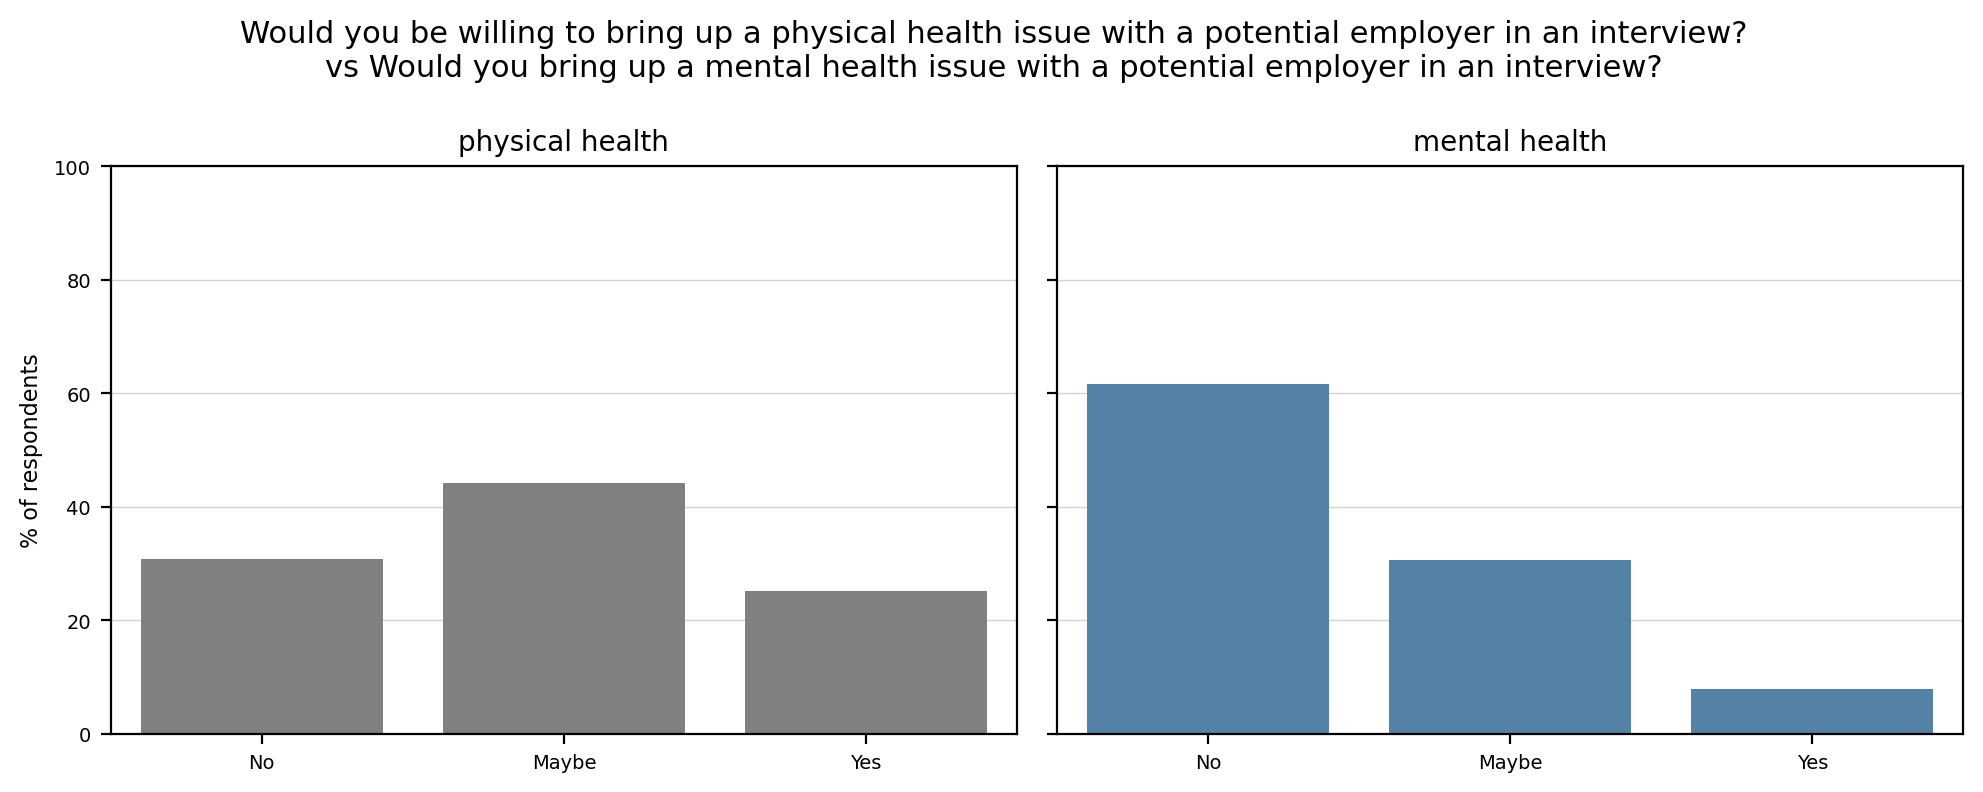

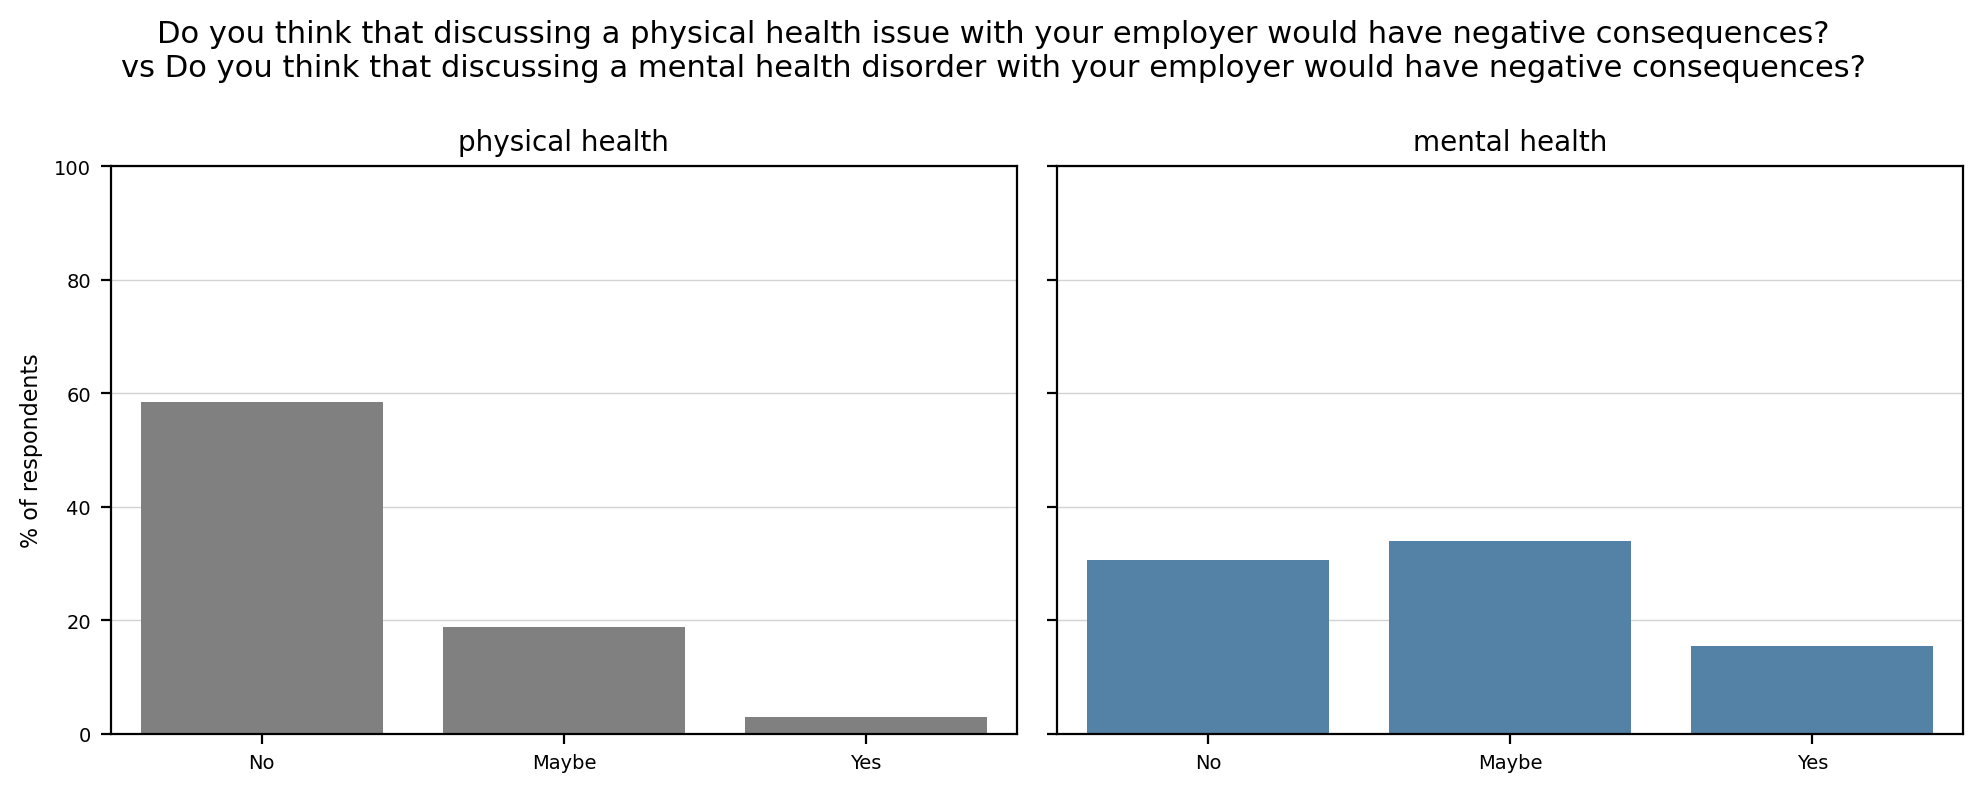

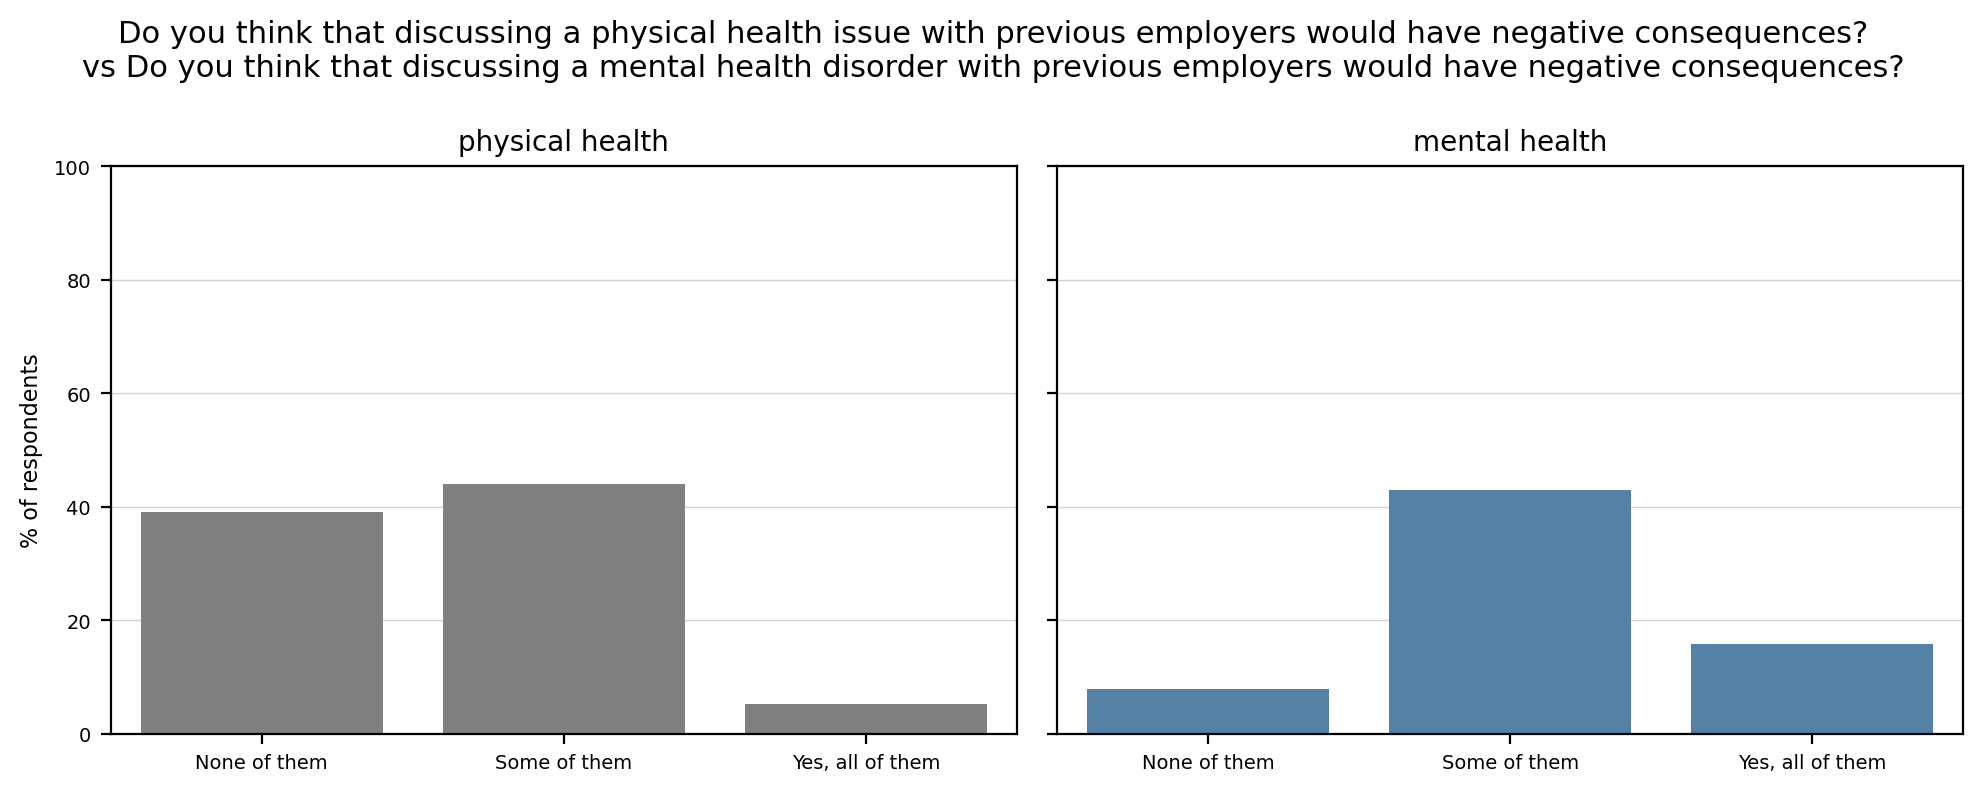

In [61]:
for questions in physical_mental_question_sests:
    if check_significant_diff_paired(questions):
        show_physical_vs_mental(questions)

#### Differences between responses from groups of employees split on industry, size of organization, location, and presence of a mental health condition

In [62]:
def check_hypothesis(question, groups = 'tech and non-tech', relation_b_groups = '<', sig_level = 0.05):
    if groups == 'tech and non-tech':
        a, b = tech_responses[question], nontech_responses[question]
    elif groups == 'us and non-us':
        a, b = us_responses[question], nonus_responses[question]
    elif groups == 'affected and not':
        a, b = aff_responses[question], nonaff_responses[question]
    elif groups == 'lg and smb':
        a, b = lc_responses[question], nonlc_responses[question]
    elif groups == 'se vs non-se':
        a, b = se_responses[question], nonse_responses[question]
    
    if relation_b_groups == '=':
        alt, relation_descr = 'two-sided', 'differences' 
    
    else:
        alt, relation_descr = 'less', 'positive differences'
        if relation_b_groups == '>':
            alt, relation_descr = 'greater', 'negative differences'
    
    stat, pval = stats.ttest_ind(a, b, alternative = alt,
                equal_var = (round(a.std(),1) == round(b.std(),1)))
        
    if pval < sig_level*(0.5)**(relation_b_groups!='='):
        #print(f'Reject null hypothesis: responses point to significant {relation_descr} in perceptions between {groups}.')
        return question
    else:
        #print(f"Not enough evidence to conclude that {groups} differ.")
        pass

In [63]:
mhit['How many employees does your company or organization have?'].value_counts()

How many employees does your company or organization have?
26-100            292
More than 1000    256
100-500           248
6-25              210
500-1000           80
1-5                60
Name: count, dtype: int64

In [66]:
se_responses = responses[responses.index.isin(demo[demo['Q1']==1].index.unique())]
nonse_responses = responses[responses.index.isin(demo[demo['Q1']==0].index.unique())]
print(se_responses.shape[0], 'responses from self-employed respondents', nonse_responses.shape[0], 'company employee responses')

287 responses from self-employed respondents 1146 company employee responses


In [67]:
lc_responses = responses[responses.index.isin(mhit[mhit['How many employees does your company or organization have?'].isin(['More than 1000', '500-1000', '100-500'])].index.unique())]
nonlc_responses = responses[~responses.index.isin(mhit[mhit['How many employees does your company or organization have?'].isin(['More than 1000', '500-1000', '100-500'])].index.unique())]
print(lc_responses.shape[0], 'responses from large company employees (100+) and', nonlc_responses.shape[0], 'smaller company employees')

584 responses from large company employees (100+) and 849 smaller company employees


In [68]:
tech_responses = responses[responses.index.isin(demo[demo['Q3']==1].index.unique())]
nontech_responses = responses[responses.index.isin(demo[demo['Q3']==0].index.unique())]
print(tech_responses.shape[0], 'responses from tech employees and', nontech_responses.shape[0], 'non-tech employee responses')

883 responses from tech employees and 263 non-tech employee responses


In [69]:
us_responses = responses[responses.index.isin(demo[demo['Q60']=='United States of America'].index.unique())]
nonus_responses = responses[responses.index.isin(demo[demo['Q60']!='United States of America'].index.unique())]
print(us_responses.shape[0], 'responses from US employees and', nonus_responses.shape[0], 'non-US employee responses')

851 responses from US employees and 582 non-US employee responses


In [70]:
aff_responses = responses[responses.index.isin(set(list(diagnosed_conditions[diagnosed_conditions.T.sum()>0].index)
                                                    +list(current_conditions[current_conditions.T.sum()>0].index)))]
nonaff_responses = responses[~responses.index.isin(aff_responses.index.unique())]
print(aff_responses.shape[0], 'responses from employees affected by mental conditions and', nonaff_responses.shape[0], 'from not affected employees')

973 responses from employees affected by mental conditions and 460 from not affected employees


In [71]:
significant_diff = {sign: {} for sign in ['<', '>', '=']}


for sign in ['<', '>', '=']:
    significant_diff[sign]['tech_vs_nontech'] = []
    for qid in responses.columns:
        try:
            significant_diff[sign]['tech_vs_nontech'].append(check_hypothesis(qid, relation_b_groups=sign))
        except:
            pass

$H_{0}$: $\mu_{t}>= \mu_{nt}$     
$H_{1}$: $\mu_{t}<  \mu_{nt}$

In [73]:
for question in set(significant_diff['<']['tech_vs_nontech']):
    if not question == None:
        print(mhit_question_ids_rev[question])

Does your employer offer resources to learn more about mental health concerns and options for seeking help?
Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?


$H_{0}$: $\mu_{t}<= \mu_{nt}$     
$H_{1}$: $\mu_{t}>  \mu_{nt}$

In [74]:
for question in set(significant_diff['>']['tech_vs_nontech']):
    if not question == None:
        print(mhit_question_ids_rev[question])

Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?
Would you feel comfortable discussing a mental health disorder with your coworkers?
Do you think that discussing a mental health disorder with your employer would have negative consequences?


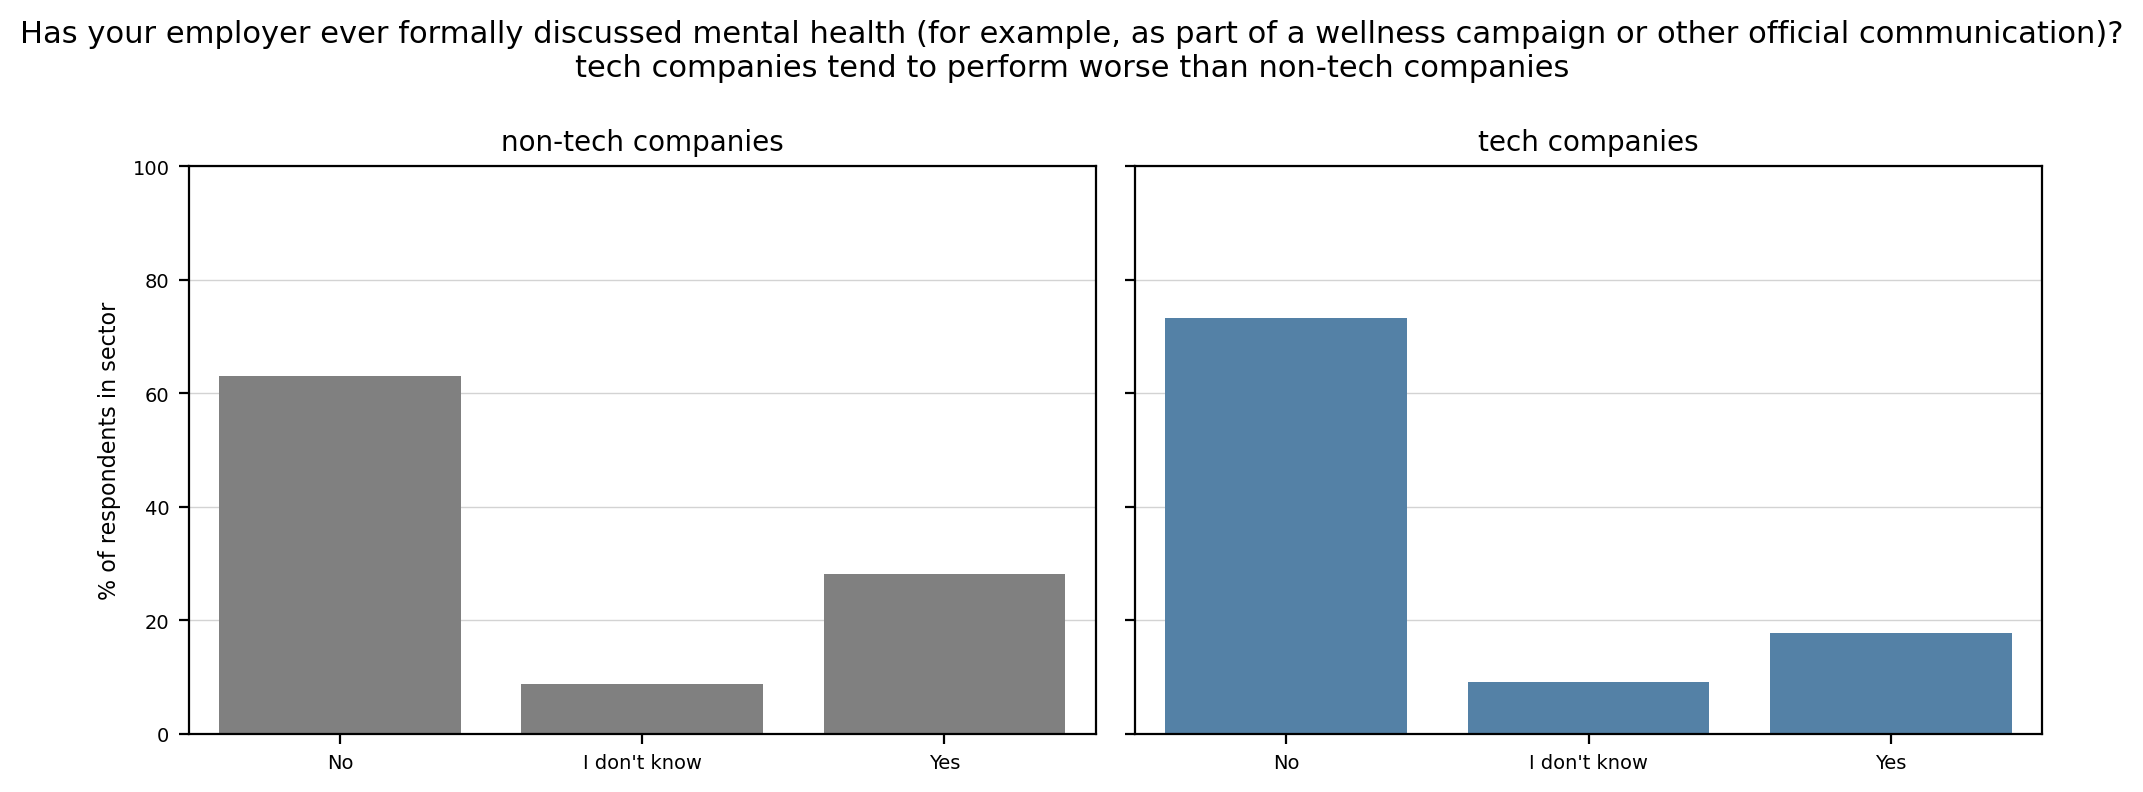

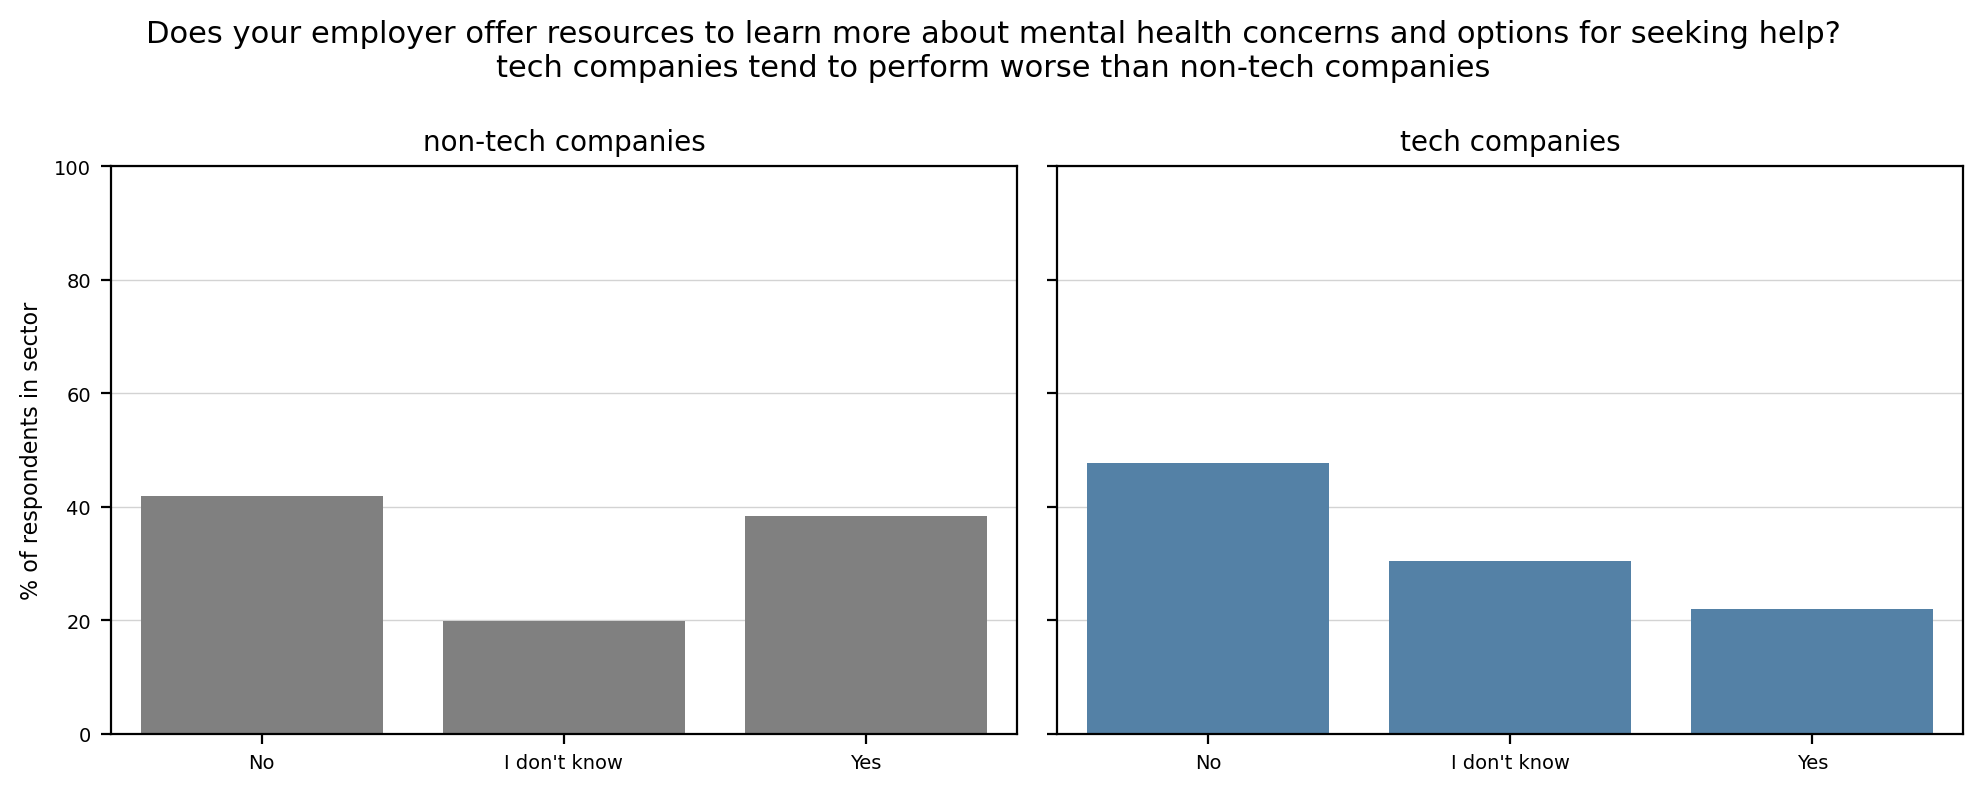

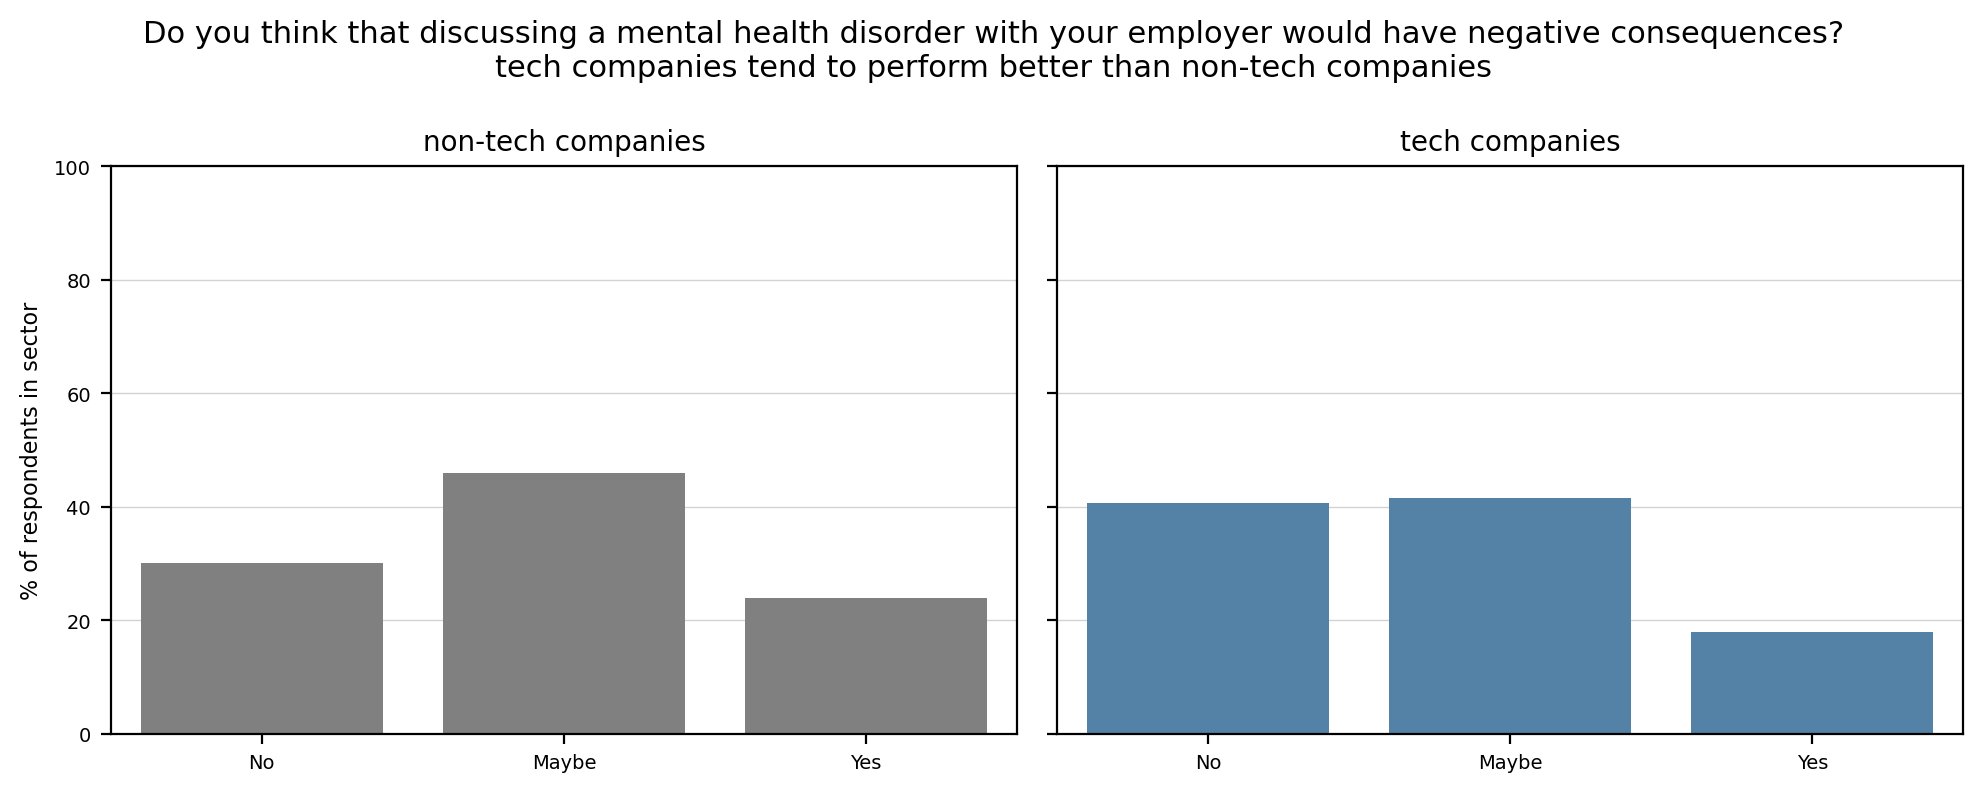

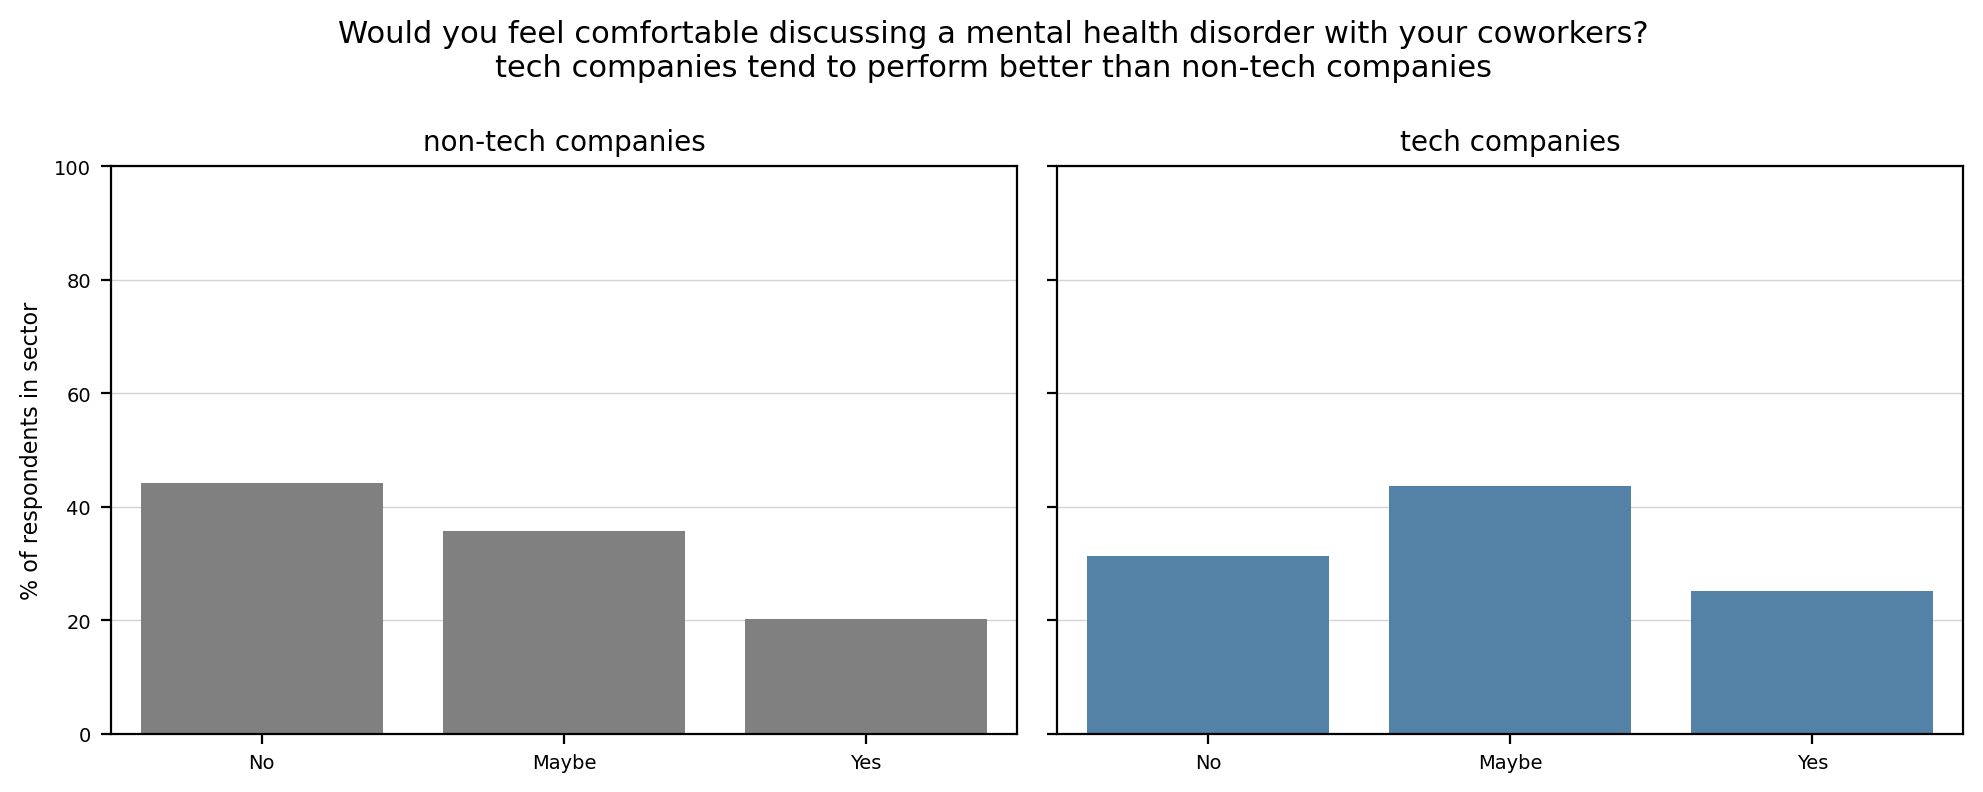

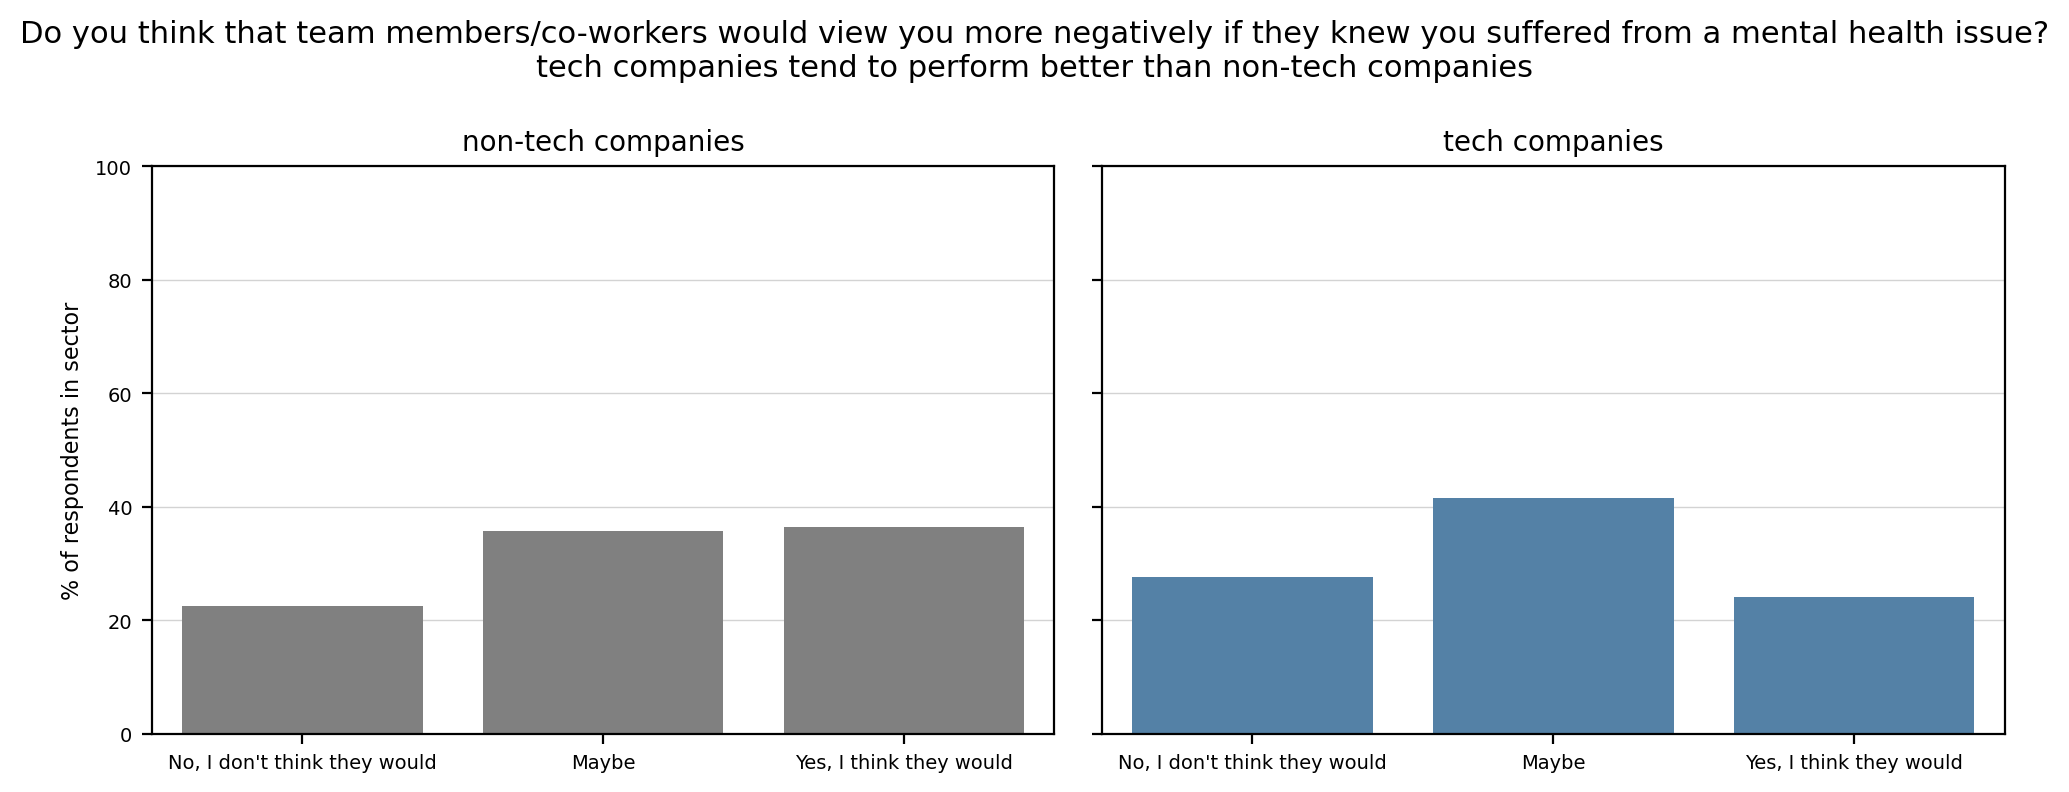

In [75]:
for question in (list(significant_diff['<']['tech_vs_nontech'])+
                 list(significant_diff['>']['tech_vs_nontech'])):
    if not question == None:
        bow = ['better', 'worse'][question in significant_diff['<']['tech_vs_nontech']]
        num_to_verbal = {n: v for v, n in zip(mhit[mhit_question_ids_rev[question]].dropna(), responses[question].dropna())}
        fig, axs = plt.subplots(1,2, figsize = (10, 4), sharey=True)
        plt.suptitle(f"{mhit_question_ids_rev[question]}\ntech companies tend to perform {bow} than non-tech companies", fontsize = 11)
        for i in range(2):
            sns.countplot(data = mhit[mhit['Is your employer primarily a tech company/organization?']==i],
                         x = mhit_question_ids_rev[question], color = ['gray', 'steelblue'][i], stat = 'percent', ax = axs[i],
                          order = [num_to_verbal[n] for n in sorted(num_to_verbal.keys(), reverse = ('Yes' in num_to_verbal[0]))])
            axs[i].set_ylim(0,100)
            axs[i].set_title(['non-tech companies', 'tech companies'][i], fontsize = 10)
            axs[i].set_xlabel('')
            axs[i].set_ylabel('% of respondents in sector')
            axs[i].grid(axis = 'y', which = 'major', zorder = 1)
            axs[i].set_axisbelow(True)

        plt.tight_layout()
        plt.show()

##### Differences between responses from large company employees vs SMB employees

In [76]:
for sign in ['<', '>', '=']:
    significant_diff[sign]['lg_vs_smb'] = []
    for qid in responses.columns:
        try:
            significant_diff[sign]['lg_vs_smb'].append(check_hypothesis(qid, groups = 'lg and smb', relation_b_groups=sign))
        except:
            pass

$H_{0}$: $\mu_{l}>= \mu_{sm}$     
$H_{1}$: $\mu_{l}<  \mu_{sm}$

In [77]:
for question in set(significant_diff['<']['lg_vs_smb']):
    if not question == None:
        print(mhit_question_ids_rev[question])

Would you be willing to bring up a physical health issue with a potential employer in an interview?
Would you bring up a mental health issue with a potential employer in an interview?


$H_{0}$: $\mu_{l}<= \mu_{sm}$     
$H_{1}$: $\mu_{l}>  \mu_{sm}$

In [78]:
for question in set(significant_diff['>']['lg_vs_smb']):
    if not question == None:
        print(mhit_question_ids_rev[question])

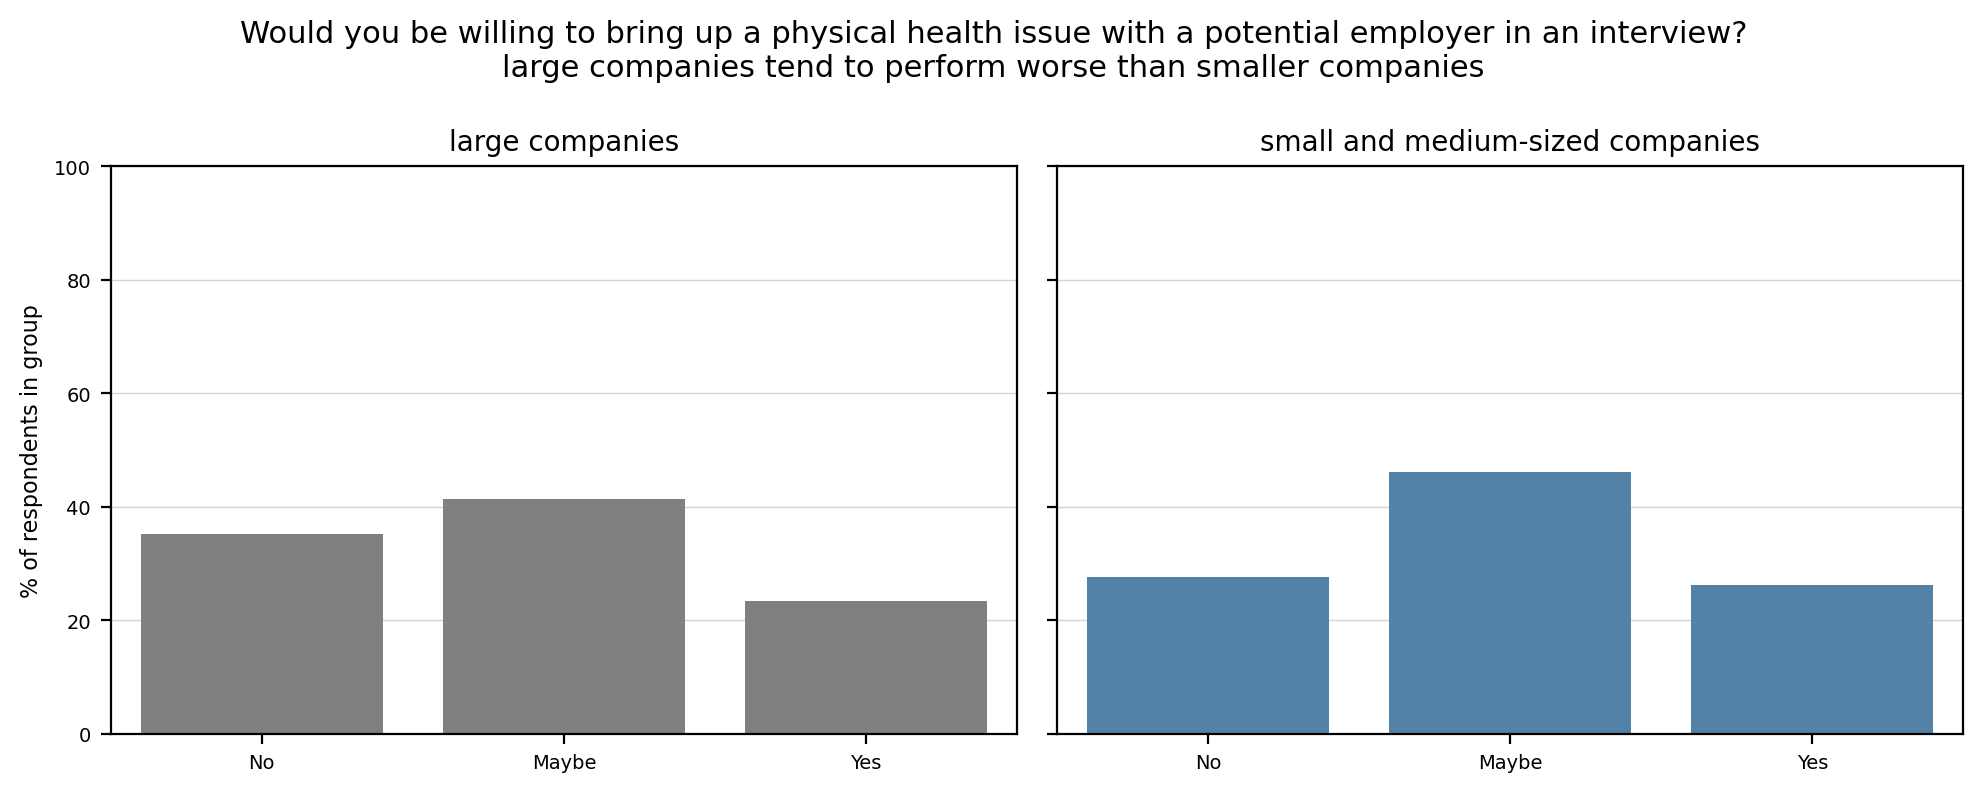

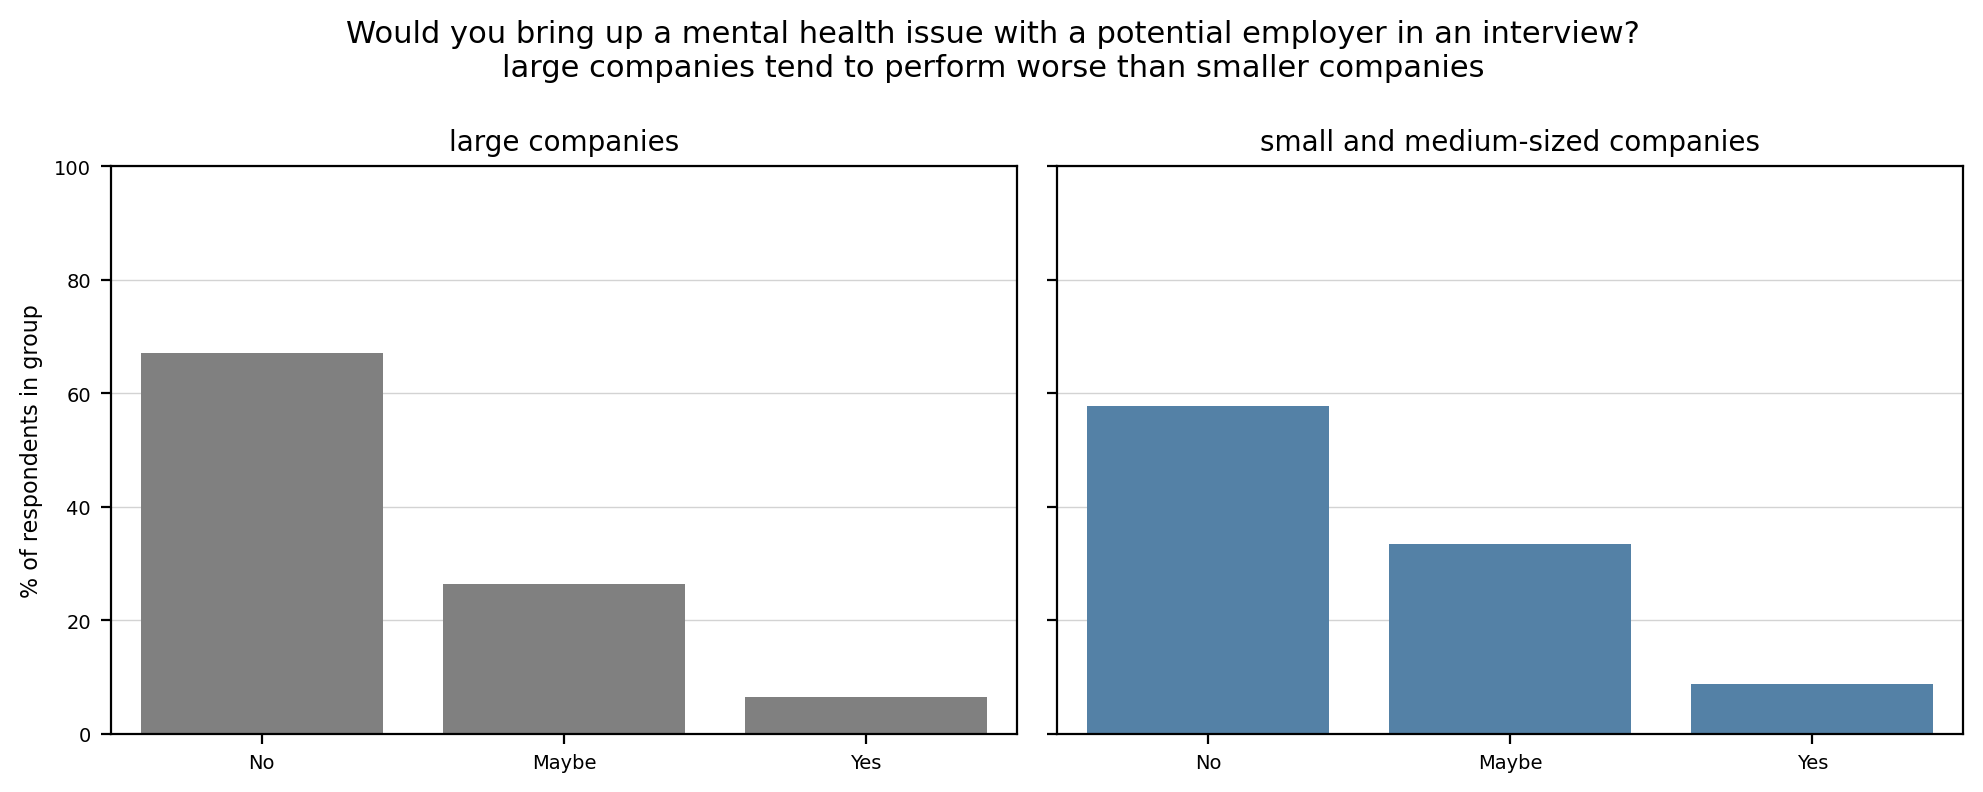

In [79]:
for question in (list(significant_diff['<']['lg_vs_smb'])
                ):
    if not question == None:
        bow = ['better', 'worse'][question in significant_diff['<']['lg_vs_smb']]
        num_to_verbal = {n: v for v, n in zip(mhit[mhit_question_ids_rev[question]].dropna(), responses[question].dropna())}
        fig, axs = plt.subplots(1,2, figsize = (10, 4), sharey=True)
        plt.suptitle(f"{mhit_question_ids_rev[question]}\nlarge companies tend to perform {bow} than smaller companies", fontsize = 11)
        conditions = [mhit.index.isin(lc_responses.index), ~mhit.index.isin(lc_responses.index)]
        for i in range(2):
            sns.countplot(data = mhit[conditions[i]],
                         x = mhit_question_ids_rev[question], color = ['gray', 'steelblue'][i], stat = 'percent', ax = axs[i],
                          order = [num_to_verbal[n] for n in sorted(num_to_verbal.keys(), reverse = ('Yes' in num_to_verbal[0]))])
            axs[i].set_ylim(0,100)
            axs[i].set_title(['large companies', 'small and medium-sized companies'][i], fontsize = 10)
            axs[i].set_xlabel('')
            axs[i].set_ylabel('% of respondents in group')
            axs[i].grid(axis = 'y', which = 'major', zorder = 1)
            axs[i].set_axisbelow(True)

        plt.tight_layout()
        plt.show()

##### Differences between responses from company employees vs self-employed workers

In [80]:
for sign in ['<', '>', '=']:
    significant_diff[sign]['se_vs_nse'] = []
    for qid in responses.columns:
        try:
            significant_diff[sign]['se_vs_nse'].append(check_hypothesis(qid, groups = 'se vs non-se', relation_b_groups=sign))
        except:
            pass

$H_{0}$: $\mu_{se}>= \mu_{nse}$     
$H_{1}$: $\mu_{se}<  \mu_{nse}$

In [81]:
for question in set(significant_diff['<']['se_vs_nse']):
    if not question == None:
        print(mhit_question_ids_rev[question])

Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?


$H_{0}$: $\mu_{se}<= \mu_{nse}$     
$H_{1}$: $\mu_{se}>  \mu_{nse}$

In [82]:
for question in set(significant_diff['>']['se_vs_nse']):
    if not question == None:
        print(mhit_question_ids_rev[question])

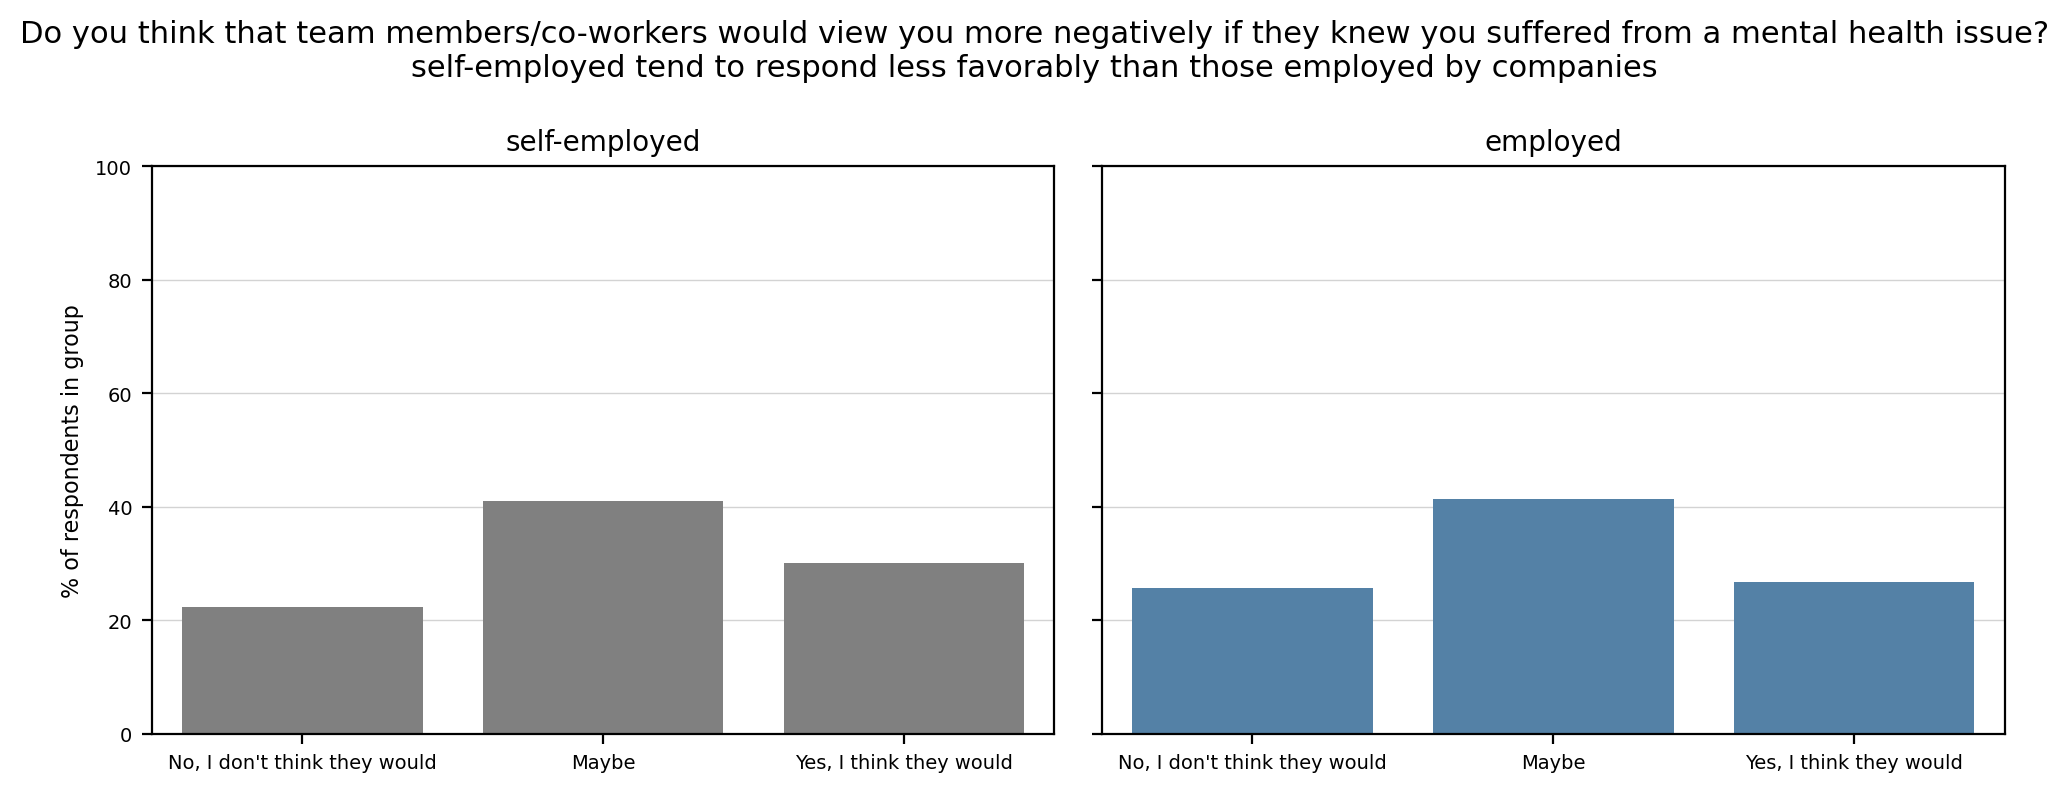

In [83]:
for question in (list(significant_diff['<']['se_vs_nse'])
                ):
    if not question == None:
        bow = ['more', 'less'][question in significant_diff['<']['se_vs_nse']]
        num_to_verbal = {n: v for v, n in zip(mhit[mhit_question_ids_rev[question]].dropna(), responses[question].dropna())}
        fig, axs = plt.subplots(1,2, figsize = (10, 4), sharey=True)
        plt.suptitle(f"{mhit_question_ids_rev[question]}\nself-employed tend to respond {bow} favorably than those employed by companies", fontsize = 11)
        conditions = [mhit.index.isin(lc_responses.index), ~mhit.index.isin(lc_responses.index)]
        for i in range(2):
            sns.countplot(data = mhit[conditions[i]],
                         x = mhit_question_ids_rev[question], color = ['gray', 'steelblue'][i], stat = 'percent', ax = axs[i],
                          order = [num_to_verbal[n] for n in sorted(num_to_verbal.keys(), reverse = ('Yes' in num_to_verbal[0]))])
            axs[i].set_ylim(0,100)
            axs[i].set_title(['self-employed', 'employed'][i], fontsize = 10)
            axs[i].set_xlabel('')
            axs[i].set_ylabel('% of respondents in group')
            axs[i].grid(axis = 'y', which = 'major', zorder = 1)
            axs[i].set_axisbelow(True)

        plt.tight_layout()
        plt.show()

##### Differences between responses from employees based in the US vs non-US employees

In [84]:
for sign in ['<', '>', '=']:
    significant_diff[sign]['us_vs_nonus'] = []
    for qid in responses.columns:
        try:
            significant_diff[sign]['us_vs_nonus'].append(check_hypothesis(qid, groups = 'US and non US', relation_b_groups=sign))
        except:
            pass

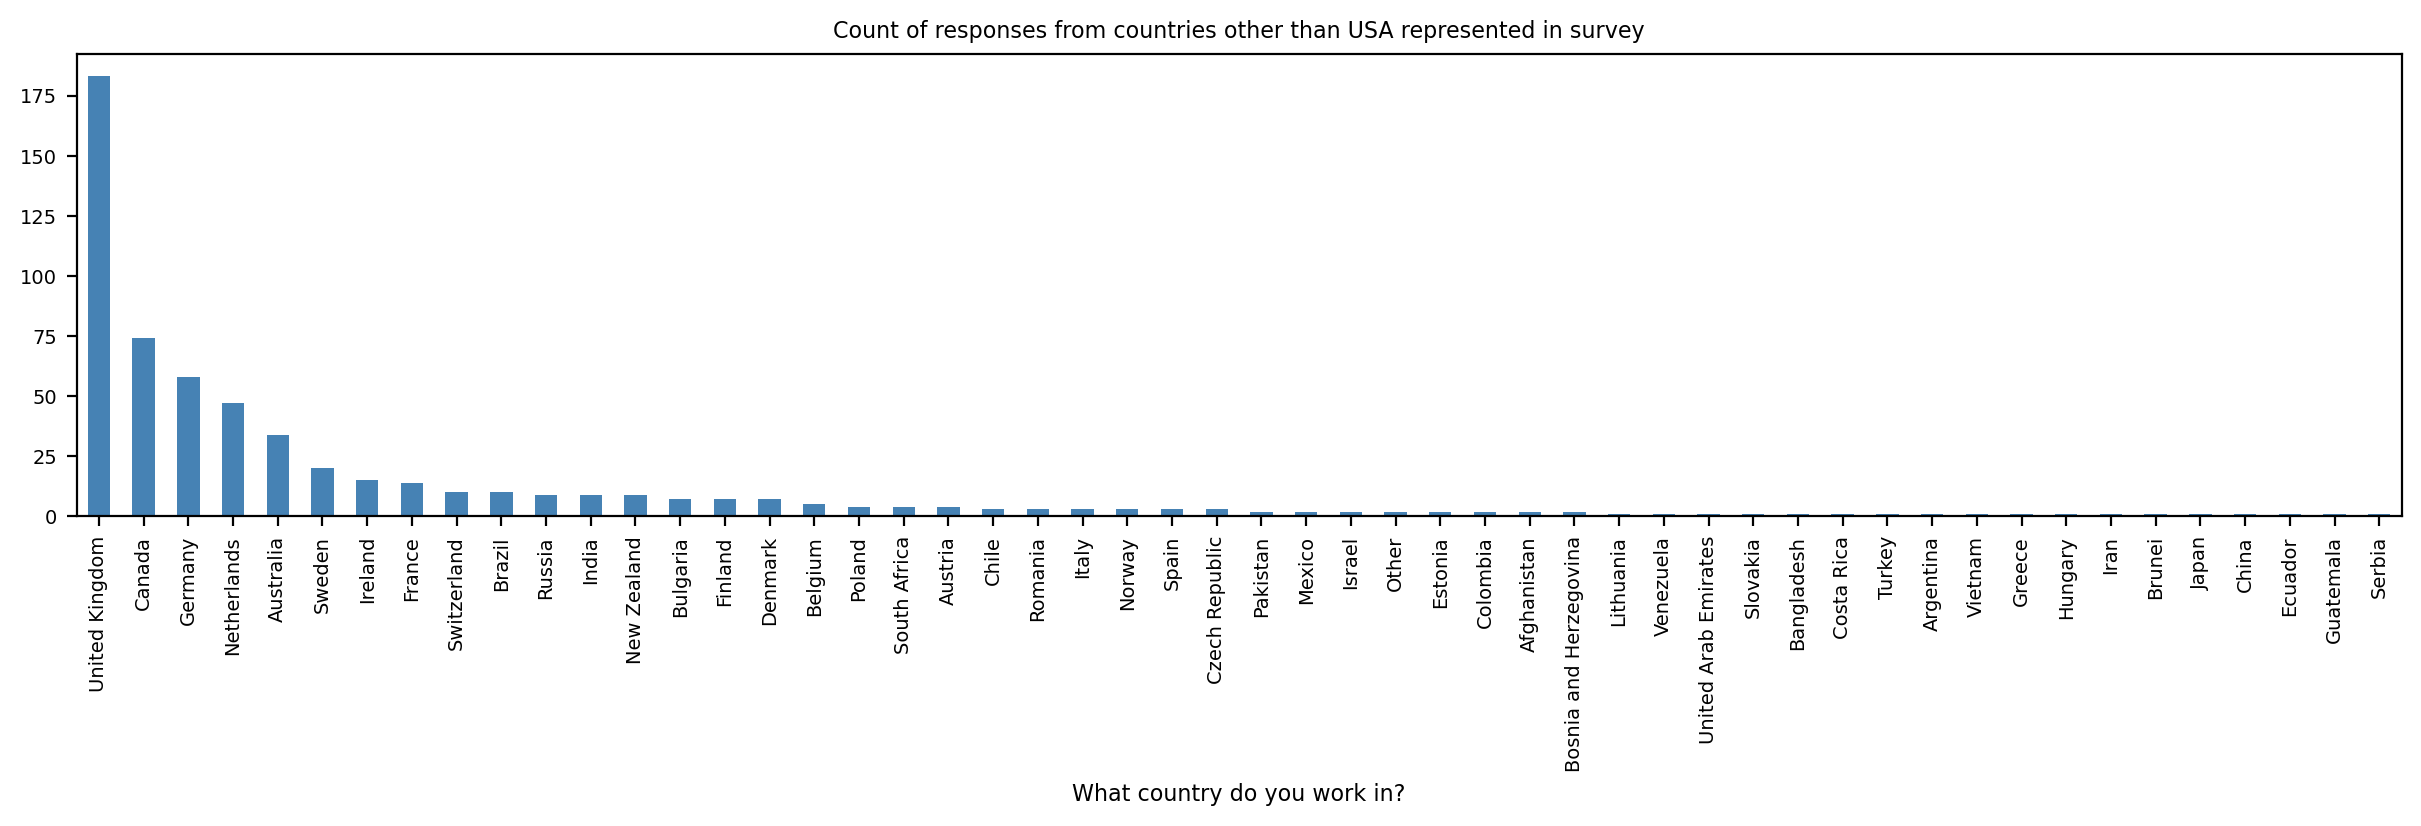

In [85]:
mhit[mhit['What country do you work in?']!='United States of America']['What country do you work in?'].value_counts().plot(kind = 'bar', figsize = (15,3))
plt.xticks(range(mhit[mhit['What country do you work in?']!='United States of America']['What country do you work in?'].value_counts().shape[0]),
          mhit[mhit['What country do you work in?']!='United States of America']['What country do you work in?'].value_counts().index, 
          rotation = 90)
plt.title('Count of responses from countries other than USA represented in survey');

$H_{0}$: $\mu_{US}>= \mu_{non-US}$     
$H_{1}$: $\mu_{US}<  \mu_{non-US}$

In [86]:
for question in set(significant_diff['<']['us_vs_nonus']):
    if not question == None:
        print(mhit_question_ids_rev[question])

$H_{0}$: $\mu_{US}<= \mu_{non-US}$     
$H_{1}$: $\mu_{US}>  \mu_{non-US}$

In [88]:
for question in set(significant_diff['>']['us_vs_nonus']):
    if not question == None:
        print(mhit_question_ids_rev[question])

In [90]:
for question in (list(significant_diff['<']['us_vs_nonus'])
                ):
    if not question == None:
        bow = ['better', 'worse'][question in significant_diff['<']['us_vs_nonus']]
        num_to_verbal = {n: v for v, n in zip(mhit[mhit_question_ids_rev[question]].dropna(), responses[question].dropna())}
        fig, axs = plt.subplots(1,2, figsize = (10, 4), sharey=True)
        plt.suptitle(f"{mhit_question_ids_rev[question]}\nUS companies tend to perform {bow} than non-US companies", fontsize = 11)
        conditions = [mhit['What country do you work in?']=='United States of America', 
                      mhit['What country do you work in?']!='United States of America']
        for i in range(2):
            sns.countplot(data = mhit[conditions[i]],
                         x = mhit_question_ids_rev[question], color = ['gray', 'steelblue'][i], stat = 'percent', ax = axs[i],
                          order = [num_to_verbal[n] for n in sorted(num_to_verbal.keys(), reverse = ('Yes' in num_to_verbal[0]))])
            axs[i].set_ylim(0,100)
            axs[i].set_title(['US companies', 'non-US companies'][i], fontsize = 10)
            axs[i].set_xlabel('')
            axs[i].set_ylabel('% of respondents in geo')
            axs[i].grid(axis = 'y', which = 'major', zorder = 1)
            axs[i].set_axisbelow(True)

        plt.tight_layout()
        plt.show()

#### Differences between responses from employees affected by mental health conditions vs unaffected employees

V1: All employees who either declared they do or "maybe" have a condition or have been diagnosed with a condition are considered "affected"

In [92]:
for sign in ['<', '>', '=']:
    significant_diff[sign]['aff_vs_noaff'] = []
    for qid in responses.columns:
        try:
            significant_diff[sign]['aff_vs_noaff'].append(check_hypothesis(qid, groups = 'affected and not', relation_b_groups=sign))
        except:
            pass

$H_{0}$: $\mu_{a}>= \mu_{na}$     
$H_{1}$: $\mu_{a}<  \mu_{na}$

In [93]:
for question in set(significant_diff['<']['aff_vs_noaff']):
    if not question == None:
        print(mhit_question_ids_rev[question])

Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?
Would you bring up a mental health issue with a potential employer in an interview?


$H_{0}$: $\mu_{a}<= \mu_{na}$     
$H_{1}$: $\mu_{a}>  \mu_{na}$

In [94]:
for question in set(significant_diff['>']['aff_vs_noaff']):
    if not question == None:
        print(mhit_question_ids_rev[question])

Have you ever sought treatment for a mental health issue from a mental health professional?
Have you been diagnosed with a mental health condition by a medical professional?
Have you had a mental health disorder in the past?
Do you currently have a mental health disorder?
Do you have a family history of mental illness?


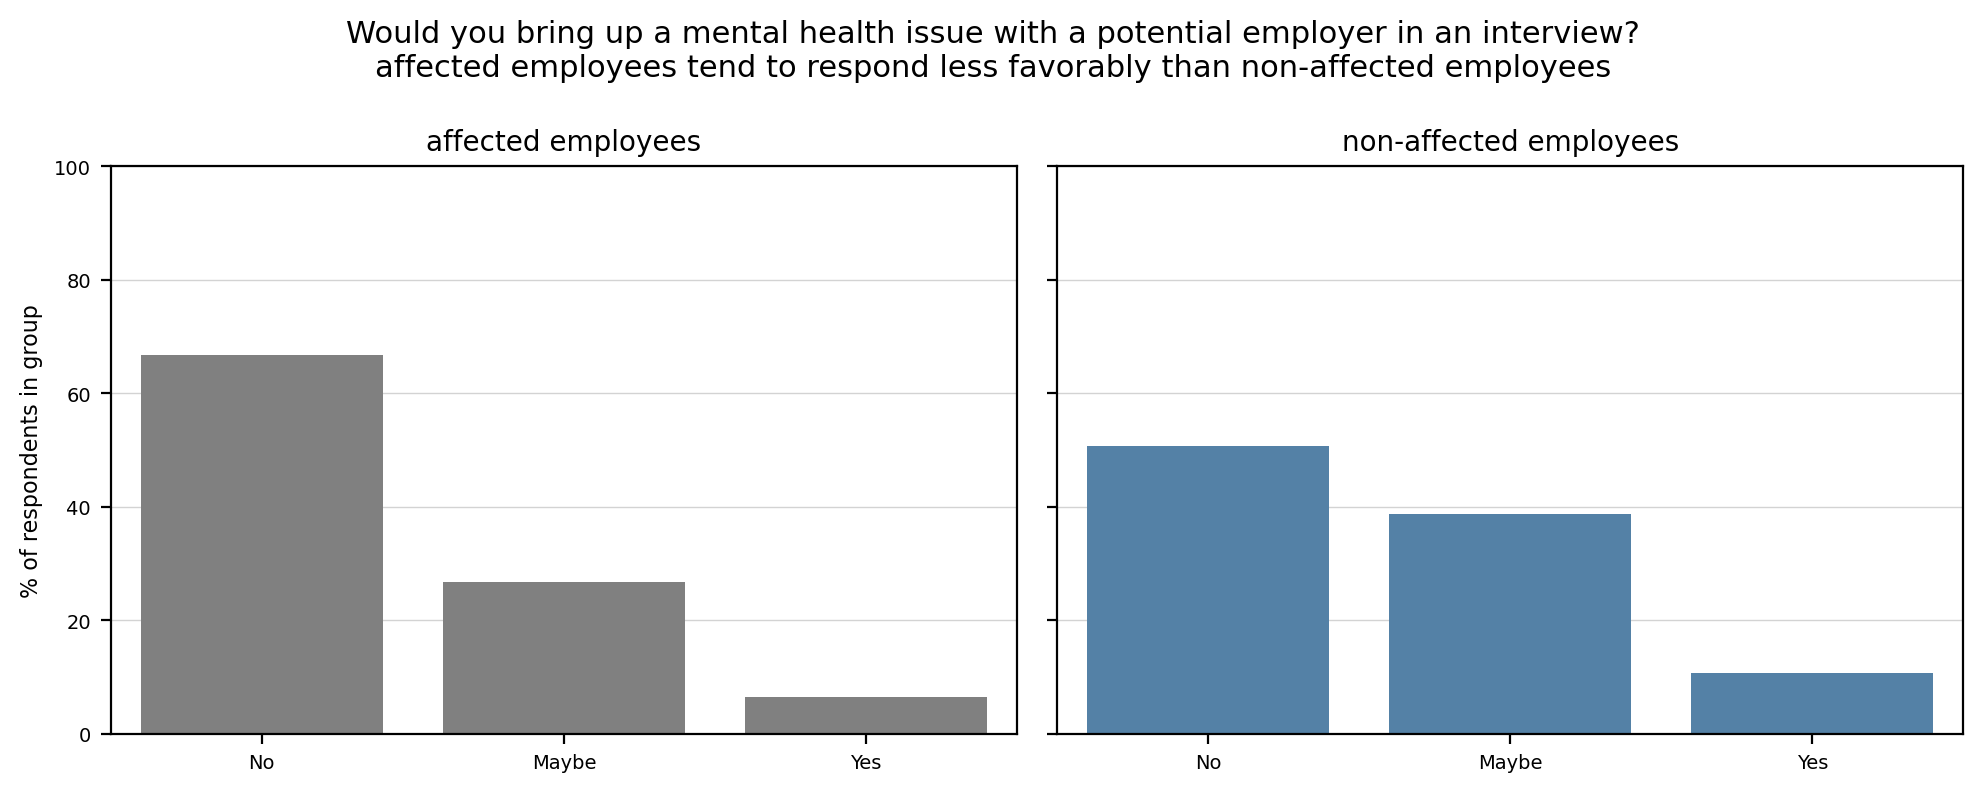

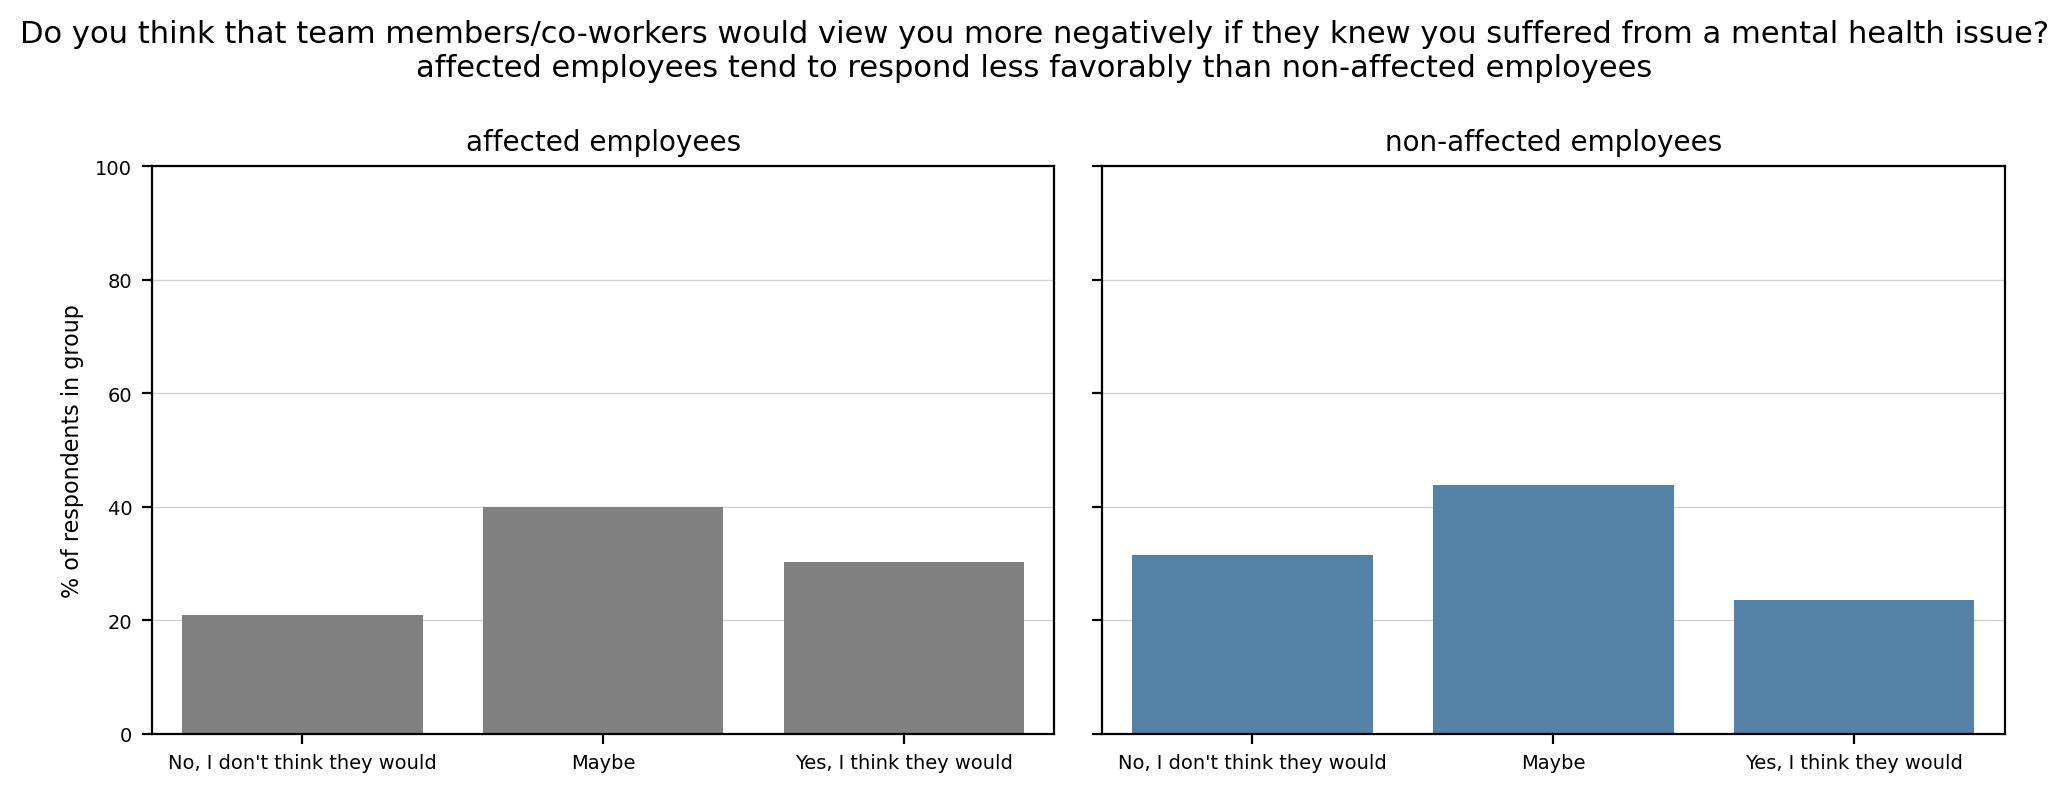

In [96]:
for question in (list(significant_diff['<']['aff_vs_noaff'])
                # +list(.significant_diff['>']['tech_vs_nontech'])
                ):
    if not question == None:
        bow = ['more', 'less'][question in significant_diff['<']['aff_vs_noaff']]
        num_to_verbal = {n: v for v, n in zip(mhit[mhit_question_ids_rev[question]].dropna(), responses[question].dropna())}
        fig, axs = plt.subplots(1,2, figsize = (10, 4), sharey=True)
        plt.suptitle(f"{mhit_question_ids_rev[question]}\naffected employees tend to respond {bow} favorably than non-affected employees", fontsize = 11)
        conditions = [mhit.index.isin(aff_responses.index), 
                     ~mhit.index.isin(aff_responses.index)]
        for i in range(2):
            sns.countplot(data = mhit[conditions[i]],
                         x = mhit_question_ids_rev[question], color = ['gray', 'steelblue'][i], stat = 'percent', ax = axs[i],
                          order = [num_to_verbal[n] for n in sorted(num_to_verbal.keys(), reverse = ('Yes' in num_to_verbal[0]))])
            axs[i].set_ylim(0,100)
            axs[i].set_title(['affected employees', 'non-affected employees'][i], fontsize = 10)
            axs[i].set_xlabel('')
            axs[i].set_ylabel('% of respondents in group')
            axs[i].grid(axis = 'y', which = 'major', zorder = 1)
            axs[i].set_axisbelow(True)

        plt.tight_layout()
        plt.show()

V2<br>Employees who either declared they do have a condition or have been diagnosed with a condition are considered "affected".<br> All employees who declared they "maybe" have a condition are considered "maybe affected".<br> Employees who declared they do not have and have not been diagnosed are considered "not affected".

In [97]:
yaff_responses = responses[responses.index.isin(set(list(diagnosed_conditions[diagnosed_conditions.T.sum()==1].index)
                                                    +list(current_conditions[current_conditions.T.sum()==1].index)))]
maff_responses = responses[responses.index.isin(set(list(diagnosed_conditions[diagnosed_conditions.T.sum()==0.5].index)
                                                    +list(current_conditions[current_conditions.T.sum()==0.5].index)))]
naff_responses = responses[responses.index.isin(set(list(diagnosed_conditions[diagnosed_conditions.T.sum()==0].index)
                                                    +list(current_conditions[current_conditions.T.sum()==0].index)))]
print(yaff_responses.shape[0], 'responses from employees affected by mental conditions and', maff_responses.shape[0], 'from maybe affected employees', naff_responses.shape[0], 'from not affected employees')

238 responses from employees affected by mental conditions and 60 from maybe affected employees 805 from not affected employees


In [98]:
def check_aff_maff_naff(question, sig_level = 0.05):
    F, p_value = stats.f_oneway(aff_responses[question], maff_responses[question], naff_responses[question])
    if p_value < sig_level:
        return question

$H_{0}$: $\mu_{y}= \mu_{m}= \mu_{n} $ **or** The mean of the samples is the same.      
$H_{1}$: At least one of them is different.    

In [99]:
significant_diff['=']['aff_vs_maff_vs_noaff'] = []
for qid in responses.columns:
    try:
        significant_diff['=']['aff_vs_maff_vs_noaff'].append(check_aff_maff_naff(qid))
    except:
        pass

In [100]:
for question in set(significant_diff['=']['aff_vs_maff_vs_noaff']):
    if not question == None:
        print(mhit_question_ids_rev[question])

Have you ever sought treatment for a mental health issue from a mental health professional?
Have you been diagnosed with a mental health condition by a medical professional?
Have you had a mental health disorder in the past?
Would you bring up a mental health issue with a potential employer in an interview?
Do you currently have a mental health disorder?
Do you have a family history of mental illness?


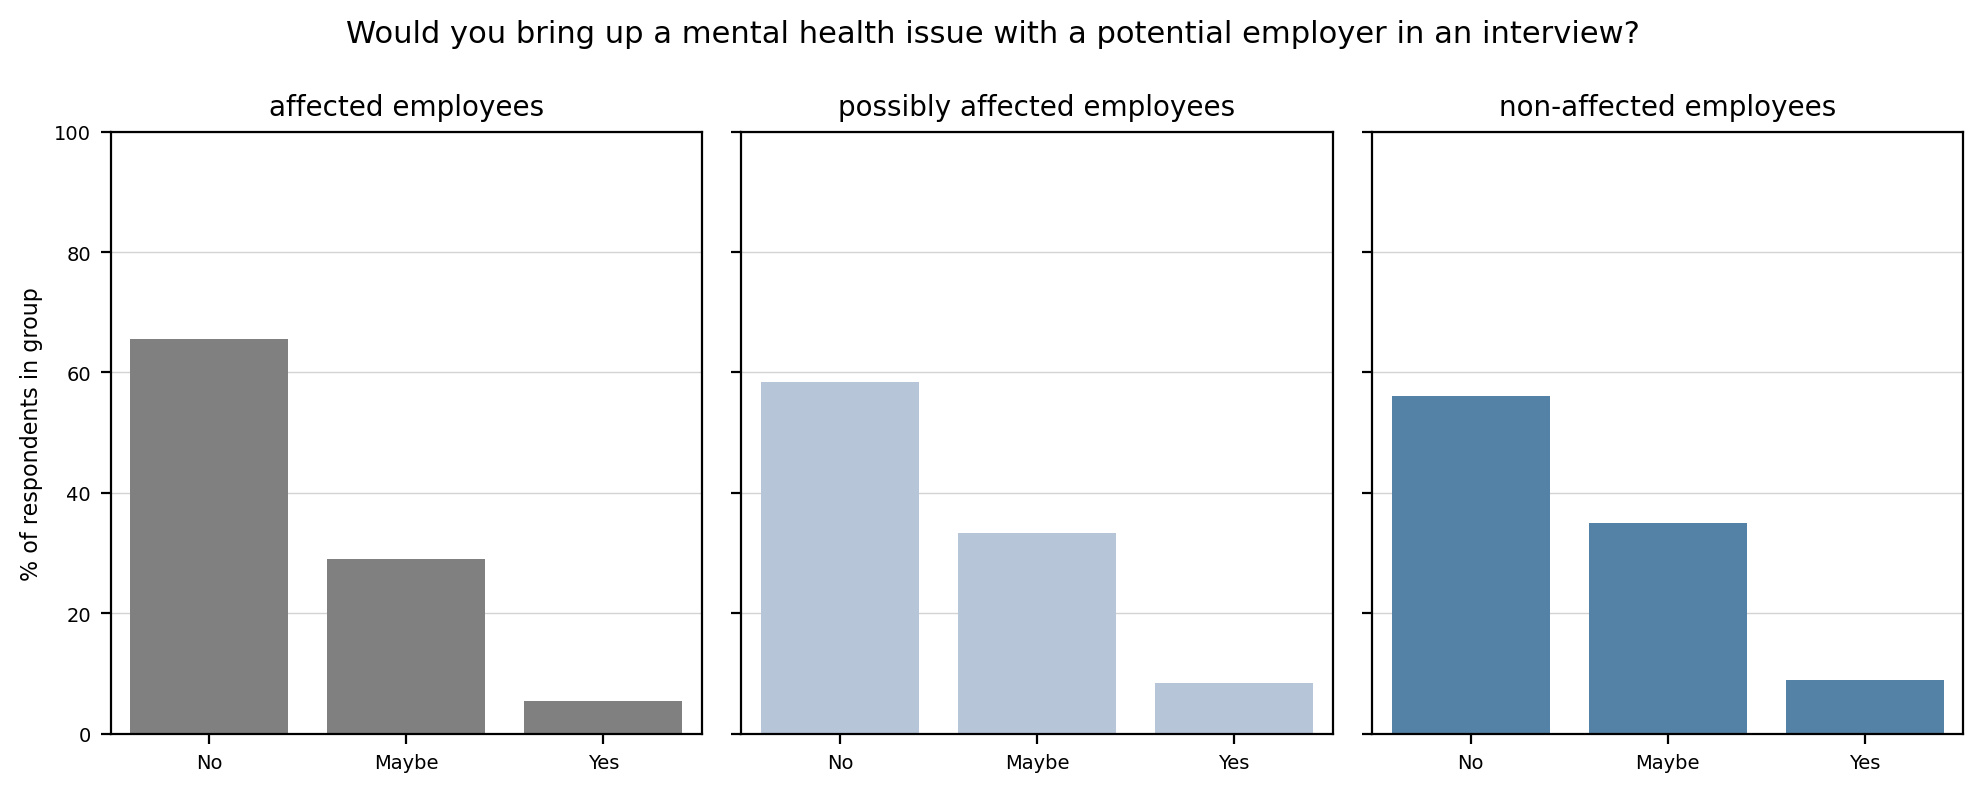

In [101]:
for question in (list(significant_diff['=']['aff_vs_maff_vs_noaff'])
                # +list(.significant_diff['>']['tech_vs_nontech'])
                ):
    if question!=None and mhit_question_ids_rev[question] == 'Would you bring up a mental health issue with a potential employer in an interview?':
        num_to_verbal = {n: v for v, n in zip(mhit[mhit_question_ids_rev[question]].dropna(), responses[question].dropna())}
        fig, axs = plt.subplots(1,3, figsize = (10, 4), sharey=True)
        plt.suptitle(f"{mhit_question_ids_rev[question]}", fontsize = 11)
        conditions = [mhit.index.isin(yaff_responses.index),
                      mhit.index.isin(maff_responses.index),
                      mhit.index.isin(naff_responses.index)]
        for i in range(3):
            sns.countplot(data = mhit[conditions[i]],
                         x = mhit_question_ids_rev[question], color = ['gray', 'lightsteelblue', 'steelblue'][i], stat = 'percent', ax = axs[i],
                          order = [num_to_verbal[n] for n in sorted(num_to_verbal.keys(), reverse = ('Yes' in num_to_verbal[0]))])
            axs[i].set_ylim(0,100)
            axs[i].set_title(['affected employees', 'possibly affected employees', 'non-affected employees'][i], fontsize = 10)
            axs[i].set_xlabel('')
            axs[i].set_ylabel('% of respondents in group')
            axs[i].grid(axis = 'y', which = 'major', zorder = 1)
            axs[i].set_axisbelow(True)

        plt.tight_layout()
        plt.show()

In [102]:
question = 'Would you bring up a mental health issue with a potential employer in an interview?'

In [103]:
ymnr = pd.concat([yaff_responses, maff_responses, naff_responses])[mhit_question_ids[question]]
ymni = pd.DataFrame(columns = ['affected?'], data = np.array(['yes'] * yaff_responses.shape[0]
                                                + ['maybe'] * maff_responses.shape[0] + ['no'] * naff_responses.shape[0]).T,
                   index = ymnr.index)

In [104]:
posthoc_df = sp.posthoc_ttest(pd.concat([ymnr, ymni], axis = 1),
                              group_col = 'affected?', val_col = mhit_question_ids[question], equal_var=True, p_adjust="bonferroni")

group_names= ["affected", "maybe affected","unaffected"]
posthoc_df.columns= group_names
posthoc_df.index= group_names
posthoc_df.style.applymap(lambda x: "background-color:lightsteelblue" if x<0.05 else "background-color: white")

/var/folders/s5/1c98d9r93rg6lzxgmf01jj0m0000gn/T/ipykernel_41301/2743149486.py:7: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  posthoc_df.style.applymap(lambda x: "background-color:lightsteelblue" if x<0.05 else "background-color: white")


,affected,maybe affected,unaffected
affected,1.000000,0.746799,0.018206
maybe affected,0.746799,1.000000,1.000000
unaffected,0.018206,1.000000,1.000000


**At the significance level of 0.05, it can be concluded that**
- "unaffected employees" responded differently than  "affected" employees